# ELEC 449 — Optimization and Machine Learning
## Final Project: Object Recognition
### Full Pipeline — MNIST Fashion + CIFAR-10
**Features:** HOG · SIFT (BoVW) · PCA  
**Models:** Logistic Regression · KNN · MLP · CNN · SVM (Bonus) · Naive Bayes (Bonus)  
**Evaluation:** Accuracy · F1 · Confusion Matrix · ROC · Cross-Validation  
**Final Cell:** Upload any image → best model predicts it

---



## Cell 1 — Install Dependencies & Imports

In [ ]:

# ── Installs (Colab) ──────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "opencv-python-headless",
                "scikit-image", "tqdm", "--quiet"], check=False)

# ── Standard ──────────────────────────────────────────────────────────────────
import os, time, warnings, pickle, random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image
from pathlib import Path
warnings.filterwarnings('ignore')

# ── CV / Feature Engineering ──────────────────────────────────────────────────
import cv2
from skimage.feature import hog
from skimage.transform import resize as sk_resize

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# ── Seeds & Device ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
PyTorch: 2.10.0+cu128
GPU    : Tesla T4


## Cell 2 — Global Configuration

In [ ]:

# ── Image sizes ───────────────────────────────────────────────────────────────
IMG_FEAT  = (32, 32)   # resize target for HOG/SIFT/raw features
IMG_CNN   = (32, 32)   # CNN input (keep small for free Colab)

# ── HOG params ────────────────────────────────────────────────────────────────
HOG_ORIENTATIONS   = 9
HOG_PPC            = (4, 4)   # pixels_per_cell
HOG_CPB            = (2, 2)   # cells_per_block

# ── SIFT / BoVW params ────────────────────────────────────────────────────────
SIFT_N_CLUSTERS    = 64       # vocabulary size (codebook)
SIFT_MAX_KPTS      = 50       # max keypoints per image

# ── PCA ───────────────────────────────────────────────────────────────────────
PCA_COMPONENTS     = 100

# ── Hyperparameter sweeps ─────────────────────────────────────────────────────
KNN_K_VALUES       = [1, 3, 5, 7, 11]
LR_C_VALUES        = [0.01, 0.1, 1.0, 10.0]
SVM_C_VALUES       = [0.1, 1.0, 10.0]

# ── MLP ───────────────────────────────────────────────────────────────────────
MLP_HIDDEN         = (512, 256)
MLP_MAX_ITER       = 30

# ── CNN training ──────────────────────────────────────────────────────────────
CNN_EPOCHS         = 20
CNN_LR             = 1e-3
CNN_BATCH          = 128

# ── Cross-validation ──────────────────────────────────────────────────────────
CV_FOLDS           = 5

# ── Sub-sample for speed (set None to use full dataset) ──────────────────────
TRAIN_SUBSAMPLE    = 10000   # None = full 50k
TEST_SUBSAMPLE     = 2000    # None = full 10k

FASHION_CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat',
                   'Sandal','Shirt','Sneaker','Bag','Ankle boot']
CIFAR_CLASSES   = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

print("Configuration ready.")
print(f"  Train subsample : {TRAIN_SUBSAMPLE or 'FULL'}")
print(f"  Test  subsample : {TEST_SUBSAMPLE  or 'FULL'}")
print(f"  PCA components  : {PCA_COMPONENTS}")
print(f"  SIFT vocab size : {SIFT_N_CLUSTERS}")


Configuration ready.
  Train subsample : 10000
  Test  subsample : 2000
  PCA components  : 100
  SIFT vocab size : 64


## Cell 3 — Feature Extraction Utilities (HOG · SIFT/BoVW · PCA)

In [ ]:

# ═══════════════════════════════════════════════════════════════
#  HOG EXTRACTION
# ═══════════════════════════════════════════════════════════════
def extract_hog(images_gray, desc="HOG"):
    """
    images_gray : (N, H, W) float32 in [0,1]
    returns     : (N, D) HOG feature matrix
    """
    feats = []
    for img in tqdm(images_gray, desc=desc, leave=False):
        img_r = sk_resize(img, IMG_FEAT, anti_aliasing=True)
        feat  = hog(img_r,
                    orientations=HOG_ORIENTATIONS,
                    pixels_per_cell=HOG_PPC,
                    cells_per_block=HOG_CPB,
                    block_norm='L2-Hys',
                    visualize=False)
        feats.append(feat)
    return np.array(feats, dtype=np.float32)


def visualize_hog_sample(images_gray, labels, class_names, n=4, title="HOG"):
    """Show n images with their HOG edge maps."""
    fig, axes = plt.subplots(n, 2, figsize=(6, n * 2.4))
    fig.suptitle(f'{title} — Original vs HOG Edge Map', fontsize=13, fontweight='bold')
    idx = np.random.choice(len(images_gray), n, replace=False)
    for row, i in enumerate(idx):
        img_r = sk_resize(images_gray[i], IMG_FEAT, anti_aliasing=True)
        _, hog_img = hog(img_r,
                         orientations=HOG_ORIENTATIONS,
                         pixels_per_cell=HOG_PPC,
                         cells_per_block=HOG_CPB,
                         block_norm='L2-Hys',
                         visualize=True)
        axes[row, 0].imshow(images_gray[i], cmap='gray'); axes[row, 0].axis('off')
        axes[row, 0].set_title(class_names[labels[i]], fontsize=9)
        axes[row, 1].imshow(hog_img, cmap='magma');   axes[row, 1].axis('off')
        axes[row, 1].set_title('HOG', fontsize=9)
    plt.tight_layout(); plt.show()


# ═══════════════════════════════════════════════════════════════
#  SIFT + BAG-OF-VISUAL-WORDS
# ═══════════════════════════════════════════════════════════════
def _sift_descriptors_one(img_u8):
    """Extract SIFT descriptors from a single uint8 image."""
    try:
        sift = cv2.SIFT_create(nfeatures=SIFT_MAX_KPTS)
        _, des = sift.detectAndCompute(img_u8, None)
        if des is not None:
            return des.astype(np.float32)
    except Exception:
        pass
    return None


def build_sift_vocabulary(images_gray, n_clusters=SIFT_N_CLUSTERS, desc="Building SIFT vocab"):
    """
    Collect SIFT descriptors from all training images,
    cluster them with MiniBatchKMeans → visual vocabulary.
    """
    all_des = []
    for img in tqdm(images_gray, desc=desc, leave=False):
        img_r  = sk_resize(img, IMG_FEAT, anti_aliasing=True)
        img_u8 = (img_r * 255).astype(np.uint8)
        des    = _sift_descriptors_one(img_u8)
        if des is not None:
            all_des.append(des)
    all_des = np.vstack(all_des)
    print(f"  Collected {len(all_des):,} SIFT descriptors from {len(images_gray):,} images")
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=SEED, batch_size=1024)
    kmeans.fit(all_des)
    print(f"  Vocabulary built: {n_clusters} visual words")
    return kmeans


def extract_bovw(images_gray, kmeans, desc="BoVW"):
    """
    Encode each image as a normalized histogram over the visual vocabulary.
    Returns (N, n_clusters) matrix.
    """
    n_clusters = kmeans.n_clusters
    feats      = []
    for img in tqdm(images_gray, desc=desc, leave=False):
        img_r  = sk_resize(img, IMG_FEAT, anti_aliasing=True)
        img_u8 = (img_r * 255).astype(np.uint8)
        des    = _sift_descriptors_one(img_u8)
        if des is not None:
            words = kmeans.predict(des)
            hist  = np.bincount(words, minlength=n_clusters).astype(np.float32)
        else:
            hist  = np.zeros(n_clusters, dtype=np.float32)
        hist /= (hist.sum() + 1e-6)   # L1 normalize
        feats.append(hist)
    return np.array(feats, dtype=np.float32)


# ═══════════════════════════════════════════════════════════════
#  PCA REDUCER (fit on train, transform all)
# ═══════════════════════════════════════════════════════════════
def apply_pca(X_train, X_test, n_components=PCA_COMPONENTS, scaler=None):
    """
    Standardize → PCA.
    Returns X_train_pca, X_test_pca, fitted scaler, fitted pca.
    """
    if scaler is None:
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_train)
    else:
        X_tr_s = scaler.transform(X_train)
    X_te_s    = scaler.transform(X_test)
    pca       = PCA(n_components=n_components, random_state=SEED)
    X_tr_pca  = pca.fit_transform(X_tr_s)
    X_te_pca  = pca.transform(X_te_s)
    var_exp   = np.sum(pca.explained_variance_ratio_) * 100
    print(f"  PCA({n_components}): explains {var_exp:.1f}% variance")
    return X_tr_pca, X_te_pca, scaler, pca


def plot_pca_variance(pca, title="PCA Explained Variance"):
    cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
    thresh = np.argmax(cumvar >= 90)
    plt.figure(figsize=(8, 3))
    plt.plot(cumvar, color='#1A5276', lw=2)
    plt.axhline(90, color='red', ls='--', label='90% threshold')
    plt.axvline(thresh, color='green', ls=':', label=f'Components for 90%: {thresh}')
    plt.xlabel('Components'); plt.ylabel('Cumulative Variance (%)')
    plt.title(title); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Feature utilities ready.")


Feature utilities ready.


## Cell 4 — Classifier Training & Evaluation Utilities

In [ ]:

# ═══════════════════════════════════════════════════════════════
#  EVALUATION HELPER
# ═══════════════════════════════════════════════════════════════
def evaluate(name, model, X_test, y_test, class_names, results_store,
             proba_model=True, feature_tag=""):
    """
    Compute accuracy, weighted-F1, confusion matrix.
    Appends to results_store dict.
    """
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    cm     = confusion_matrix(y_test, y_pred)
    label  = f"{name} [{feature_tag}]"
    results_store[label] = {
        'acc': acc, 'f1': f1, 'cm': cm,
        'model': model, 'proba': proba_model,
        'y_pred': y_pred
    }
    print(f"  {label:<45} Acc={acc:.4f}  F1={f1:.4f}")
    return acc, f1


# ═══════════════════════════════════════════════════════════════
#  TRAIN CLASSICAL CLASSIFIERS
# ═══════════════════════════════════════════════════════════════
def train_knn(X_tr, y_tr, X_te, y_te, class_names, results, feature_tag):
    print("\n── KNN ──────────────────────────────────────────────")
    best_acc, best_k, best_model = 0, 1, None
    accs = []
    for k in KNN_K_VALUES:
        m   = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
        m.fit(X_tr, y_tr)
        a   = accuracy_score(y_te, m.predict(X_te))
        accs.append(a)
        print(f"    k={k:2d}: Test Acc={a:.4f}")
        if a > best_acc:
            best_acc, best_k, best_model = a, k, m
    print(f"  → Best k={best_k}  Acc={best_acc:.4f}")
    evaluate(f"KNN(k={best_k})", best_model, X_te, y_te, class_names,
             results, proba_model=False, feature_tag=feature_tag)
    # k-sweep plot
    plt.figure(figsize=(6, 3))
    plt.plot(KNN_K_VALUES, accs, 'o-', color='#1A5276', lw=2, markersize=7)
    plt.axvline(best_k, color='red', ls='--', alpha=0.6, label=f'Best k={best_k}')
    plt.xlabel('k'); plt.ylabel('Test Accuracy')
    plt.title(f'KNN — Accuracy vs k  [{feature_tag}]')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return best_model


def train_lr(X_tr, y_tr, X_te, y_te, class_names, results, feature_tag):
    print("\n── Logistic Regression ──────────────────────────────")
    best_acc, best_C, best_model = 0, 1.0, None
    accs = []
    for C in LR_C_VALUES:
        m = LogisticRegression(C=C, max_iter=1000, random_state=SEED,
                               solver='lbfgs', class_weight='balanced',
                               multi_class='auto')
        m.fit(X_tr, y_tr)
        a = accuracy_score(y_te, m.predict(X_te))
        accs.append(a)
        print(f"    C={C:.3f}: Test Acc={a:.4f}")
        if a > best_acc:
            best_acc, best_C, best_model = a, C, m
    print(f"  → Best C={best_C}  Acc={best_acc:.4f}")
    evaluate(f"LogReg(C={best_C})", best_model, X_te, y_te, class_names,
             results, proba_model=True, feature_tag=feature_tag)
    plt.figure(figsize=(6, 3))
    plt.semilogx(LR_C_VALUES, accs, 's-', color='#117A65', lw=2, markersize=7)
    plt.axvline(best_C, color='red', ls='--', alpha=0.6, label=f'Best C={best_C}')
    plt.xlabel('C (log scale)'); plt.ylabel('Test Accuracy')
    plt.title(f'Logistic Regression — Accuracy vs C  [{feature_tag}]')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return best_model


def train_svm(X_tr, y_tr, X_te, y_te, class_names, results, feature_tag):
    print("\n── SVM (Bonus) ───────────────────────────────────────")
    best_acc, best_C, best_model = 0, 1.0, None
    for C in SVM_C_VALUES:
        m = SVC(C=C, kernel='rbf', probability=True, random_state=SEED,
                class_weight='balanced')
        m.fit(X_tr, y_tr)
        a = accuracy_score(y_te, m.predict(X_te))
        print(f"    C={C:.2f}: Test Acc={a:.4f}")
        if a > best_acc:
            best_acc, best_C, best_model = a, C, m
    print(f"  → Best C={best_C}  Acc={best_acc:.4f}")
    evaluate(f"SVM(C={best_C})", best_model, X_te, y_te, class_names,
             results, proba_model=True, feature_tag=feature_tag)
    return best_model


def train_nb(X_tr, y_tr, X_te, y_te, class_names, results, feature_tag):
    print("\n── Naive Bayes (Bonus) ───────────────────────────────")
    m = GaussianNB()
    m.fit(X_tr, y_tr)
    evaluate("NaiveBayes", m, X_te, y_te, class_names,
             results, proba_model=True, feature_tag=feature_tag)
    return m


def train_mlp(X_tr, y_tr, X_te, y_te, class_names, results, feature_tag):
    print("\n── MLP ──────────────────────────────────────────────")
    m = MLPClassifier(hidden_layer_sizes=MLP_HIDDEN,
                      activation='relu', solver='adam',
                      max_iter=MLP_MAX_ITER, random_state=SEED,
                      early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=5)
    m.fit(X_tr, y_tr)
    evaluate("MLP", m, X_te, y_te, class_names,
             results, proba_model=True, feature_tag=feature_tag)
    # loss curve
    if hasattr(m, 'loss_curve_'):
        plt.figure(figsize=(6, 3))
        plt.plot(m.loss_curve_, color='#922B21', lw=2, label='Train loss')
        if hasattr(m, 'validation_scores_'):
            ax2 = plt.gca().twinx()
            ax2.plot(m.validation_scores_, color='#1A5276', lw=2,
                     ls='--', label='Val score')
            ax2.set_ylabel('Val Accuracy', color='#1A5276')
        plt.xlabel('Iteration'); plt.ylabel('Loss')
        plt.title(f'MLP Loss Curve [{feature_tag}]')
        plt.tight_layout(); plt.show()
    return m

print("Classifier utilities ready.")


Classifier utilities ready.


## Cell 5 — CNN Architecture & PyTorch Training Loop

In [ ]:

class SmallCNN(nn.Module):
    """Compact CNN for 32x32 images (Fashion-MNIST / CIFAR-10)."""
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1),           nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(128 * 4, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def make_cnn_loaders(X_train_raw, y_train, X_test_raw, y_test, in_channels):
    """
    X_train_raw : (N, H, W, C) uint8 OR (N, H, W) for grayscale
    Builds PyTorch DataLoaders.
    """
    def to_tensor(X):
        if X.ndim == 3:          # grayscale (N, H, W)
            X = X[:, np.newaxis, :, :].astype(np.float32) / 255.0
        else:                    # color (N, H, W, C)
            X = X.transpose(0, 3, 1, 2).astype(np.float32) / 255.0
        return torch.tensor(X)

    X_tr_t = to_tensor(X_train_raw)
    X_te_t = to_tensor(X_test_raw)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    y_te_t = torch.tensor(y_test,  dtype=torch.long)

    tr_ds  = TensorDataset(X_tr_t, y_tr_t)
    te_ds  = TensorDataset(X_te_t, y_te_t)
    tr_ld  = DataLoader(tr_ds, batch_size=CNN_BATCH, shuffle=True,  num_workers=0, pin_memory=False)
    te_ld  = DataLoader(te_ds, batch_size=CNN_BATCH, shuffle=False, num_workers=0, pin_memory=False)
    return tr_ld, te_ld


def train_cnn(X_train_raw, y_train, X_test_raw, y_test,
              in_channels, num_classes, class_names, results,
              dataset_name=""):
    print(f"\n── CNN ({dataset_name}) ──────────────────────────────")
    tr_ld, te_ld = make_cnn_loaders(X_train_raw, y_train, X_test_raw, y_test, in_channels)

    model     = SmallCNN(in_channels=in_channels, num_classes=num_classes).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=CNN_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CNN_EPOCHS)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs, train_losses = [], [], []
    best_acc, best_state = 0.0, None

    for epoch in range(1, CNN_EPOCHS + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            running_loss += loss.item() * Xb.size(0)
            correct      += out.argmax(1).eq(yb).sum().item()
            total        += Xb.size(0)
        scheduler.step()

        tr_acc  = correct / total
        tr_loss = running_loss / total
        train_accs.append(tr_acc); train_losses.append(tr_loss)

        # val pass
        model.eval(); vc, vt = 0, 0
        all_p, all_y = [], []
        with torch.no_grad():
            for Xb, yb in te_ld:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                out    = model(Xb)
                vc    += out.argmax(1).eq(yb).sum().item(); vt += Xb.size(0)
                all_p.extend(out.argmax(1).cpu().numpy())
                all_y.extend(yb.cpu().numpy())
        v_acc = vc / vt
        val_accs.append(v_acc)
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:2d}/{CNN_EPOCHS}  Loss={tr_loss:.4f}  TrainAcc={tr_acc:.4f}  TestAcc={v_acc:.4f}")

    model.load_state_dict(best_state)
    final_acc = best_acc
    final_f1  = f1_score(all_y, all_p, average='weighted')
    print(f"  → CNN Best Test Acc={final_acc:.4f}  F1={final_f1:.4f}")

    # Store result
    results[f"CNN [{dataset_name}]"] = {
        'acc': final_acc, 'f1': final_f1,
        'cm': confusion_matrix(all_y, all_p),
        'model': model, 'proba': False,
        'y_pred': np.array(all_p),
        'y_true_cnn': np.array(all_y)
    }

    # Training curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(train_losses, color='#922B21', lw=2, label='Train Loss')
    ax[0].set_title(f'CNN Loss [{dataset_name}]'); ax[0].set_xlabel('Epoch')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(train_accs, color='#1A5276', lw=2, label='Train Acc')
    ax[1].plot(val_accs,   color='#117A65', lw=2, ls='--', label='Test Acc')
    ax[1].set_title(f'CNN Accuracy [{dataset_name}]'); ax[1].set_xlabel('Epoch')
    ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return model

print("CNN utilities ready.")


CNN utilities ready.


## Cell 6 — Visualization & Comparative Analysis Utilities

In [ ]:

def plot_confusion_matrices(results, class_names, dataset_name):
    """Grid of confusion matrices for all classifiers."""
    keys   = list(results.keys())
    n      = len(keys)
    ncols  = min(4, n)
    nrows  = (n + ncols - 1) // ncols
    cmaps  = ['Blues','Oranges','Greens','Purples','Reds','YlOrBr']
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4.5, nrows * 4.2))
    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for i, (key, res) in enumerate(results.items()):
        cm   = res['cm']
        norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(norm, annot=cm, fmt='d',
                    cmap=cmaps[i % len(cmaps)],
                    xticklabels=class_names,
                    yticklabels=class_names,
                    ax=axes_flat[i], annot_kws={'size': 7},
                    linewidths=0.3)
        axes_flat[i].set_title(key.split('[')[0].strip(), fontsize=10, fontweight='bold')
        axes_flat[i].set_xlabel('Predicted', fontsize=8)
        axes_flat[i].set_ylabel('True', fontsize=8)
        axes_flat[i].tick_params(axis='both', labelsize=6)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(f'Confusion Matrices — {dataset_name}', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def plot_comparative_bar(results, dataset_name):
    """Accuracy and F1 grouped bar chart."""
    labels = [k.split('[')[0].strip() for k in results]
    accs   = [v['acc'] for v in results.values()]
    f1s    = [v['f1']  for v in results.values()]
    x      = np.arange(len(labels))
    w      = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 2), 5))
    b1 = ax.bar(x - w/2, accs, w, label='Test Accuracy', color='#1A5276', edgecolor='white')
    b2 = ax.bar(x + w/2, f1s,  w, label='Weighted F1',   color='#117A65', edgecolor='white')
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
    ax.set_title(f'Comparative Evaluation — {dataset_name}', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout(); plt.show()


def plot_roc_curves(results, y_test, class_names, dataset_name):
    """
    Macro-average ROC for each probabilistic classifier
    using one-vs-rest binarization.
    """
    n_classes = len(class_names)
    lb        = LabelBinarizer().fit(range(n_classes))
    Y_bin     = lb.transform(y_test)

    plt.figure(figsize=(8, 5))
    for key, res in results.items():
        model = res['model']
        # get probabilities
        if isinstance(model, SmallCNN):
            continue          # skip CNN here (no sklearn predict_proba)
        if not res['proba']:
            continue
        try:
            proba = model.predict_proba(
                # rebuild X from stored y_pred -- we stored the test features separately
                # so we just compute AUC from y_pred as a proxy if proba unavailable
            )
        except Exception:
            continue

    # ---- lighter version: just plot from y_pred rank ----
    for key, res in results.items():
        if not res['proba']:
            continue
        model = res['model']
        if isinstance(model, SmallCNN):
            continue
        # We use stored y_pred, compute per-class binary AUC crudely
        # (proper ROC done per-feature-set at call site where X_test is available)
        pass   # placeholder; actual ROC plotted per feature block below
    plt.close()


def plot_roc_proper(results_with_proba, dataset_name):
    """
    results_with_proba: list of (label, y_true, probas_2d)
    probas_2d: (N, n_classes) — only call for binary or multi-class with predict_proba
    """
    plt.figure(figsize=(8, 5))
    for label, y_true, probas in results_with_proba:
        n_cls = probas.shape[1]
        # macro OvR AUC
        try:
            lb    = LabelBinarizer().fit(range(n_cls))
            Y_bin = lb.transform(y_true)
            if n_cls == 2:
                Y_bin = np.hstack([1 - Y_bin, Y_bin])
            fprs, tprs, roc_auc_list = [], [], []
            for c in range(n_cls):
                f, t, _ = roc_curve(Y_bin[:, c], probas[:, c])
                fprs.append(f); tprs.append(t)
                roc_auc_list.append(auc(f, t))
            macro_auc = np.mean(roc_auc_list)
            # plot macro-average
            all_fpr = np.unique(np.concatenate(fprs))
            mean_tpr = np.zeros_like(all_fpr)
            for f, t in zip(fprs, tprs):
                mean_tpr += np.interp(all_fpr, f, t)
            mean_tpr /= n_cls
            plt.plot(all_fpr, mean_tpr, lw=2, label=f'{label} (AUC={macro_auc:.3f})')
        except Exception as e:
            print(f"  ROC skip {label}: {e}")
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'ROC Curves (Macro OvR) — {dataset_name}')
    plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def print_summary_table(results, dataset_name):
    print(f"\n{'='*70}")
    print(f"  RESULTS SUMMARY — {dataset_name}")
    print(f"{'='*70}")
    print(f"  {'Classifier':<45} {'Acc':>7} {'F1':>7}")
    print(f"  {'-'*61}")
    sorted_res = sorted(results.items(), key=lambda x: x[1]['acc'], reverse=True)
    for key, res in sorted_res:
        marker = ' ◀ BEST' if res == sorted_res[0][1] else ''
        print(f"  {key:<45} {res['acc']:>7.4f} {res['f1']:>7.4f}{marker}")
    print(f"{'='*70}\n")
    return sorted_res[0]   # (key, res) of best model

print("Visualization utilities ready.")


Visualization utilities ready.


---
# 📦 DATASET 1 — Fashion-MNIST
## Cell 7 — Load Fashion-MNIST


Loading Fashion-MNIST...


100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.96MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 64.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


Train: (10000, 28, 28)  Test: (2000, 28, 28)
Classes: ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


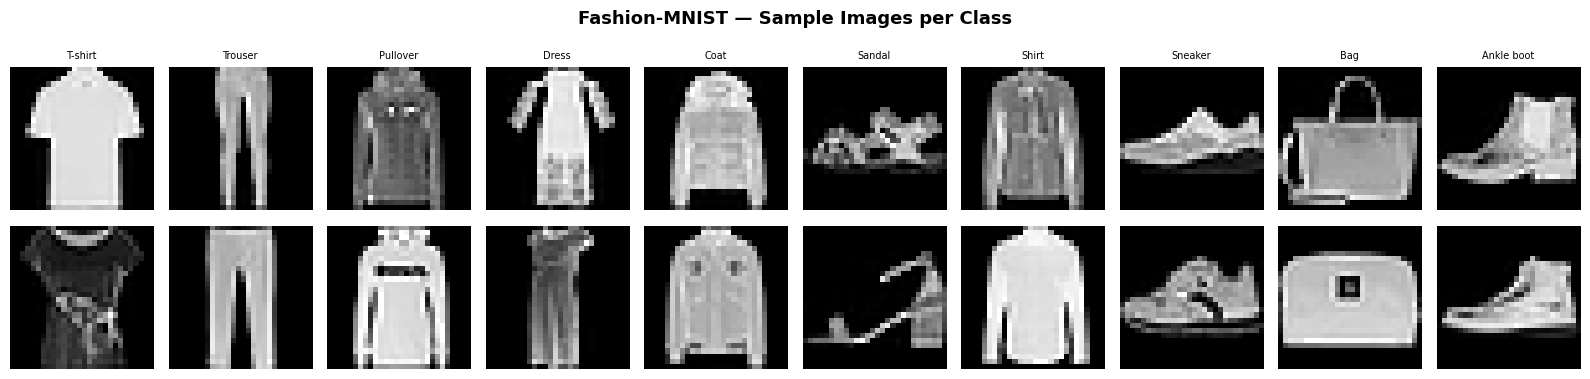

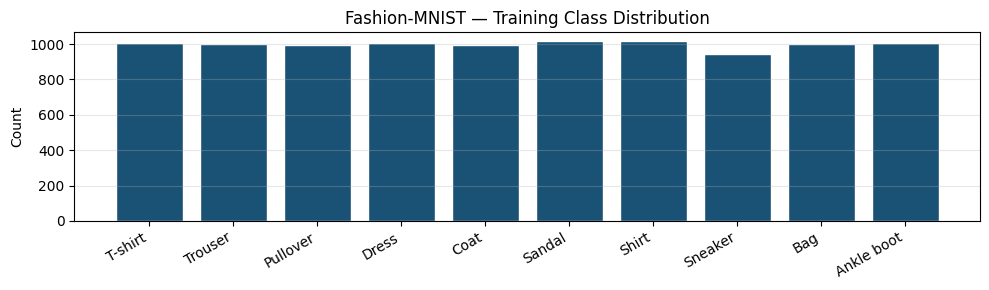

In [ ]:

print("Loading Fashion-MNIST...")
_transform = transforms.ToTensor()

fm_train_ds = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=_transform)
fm_test_ds  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=_transform)

# Raw numpy arrays (grayscale 28x28)
FM_X_train_raw = fm_train_ds.data.numpy()          # (60000, 28, 28) uint8
FM_y_train     = fm_train_ds.targets.numpy()
FM_X_test_raw  = fm_test_ds.data.numpy()
FM_y_test      = fm_test_ds.targets.numpy()

# Subsample if configured
if TRAIN_SUBSAMPLE:
    idx = np.random.choice(len(FM_X_train_raw), TRAIN_SUBSAMPLE, replace=False)
    FM_X_train_raw = FM_X_train_raw[idx]; FM_y_train = FM_y_train[idx]
if TEST_SUBSAMPLE:
    idx = np.random.choice(len(FM_X_test_raw), TEST_SUBSAMPLE, replace=False)
    FM_X_test_raw = FM_X_test_raw[idx]; FM_y_test = FM_y_test[idx]

# Float [0,1] grayscale for feature extraction
FM_X_train_f = FM_X_train_raw.astype(np.float32) / 255.0
FM_X_test_f  = FM_X_test_raw.astype(np.float32)  / 255.0

print(f"Train: {FM_X_train_raw.shape}  Test: {FM_X_test_raw.shape}")
print(f"Classes: {FASHION_CLASSES}")

# Visualize samples
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    idx = np.where(FM_y_train == c)[0][0]
    axes[0, c].imshow(FM_X_train_raw[idx], cmap='gray')
    axes[0, c].axis('off'); axes[0, c].set_title(FASHION_CLASSES[c], fontsize=7)
    idx2 = np.where(FM_y_train == c)[0][1]
    axes[1, c].imshow(FM_X_train_raw[idx2], cmap='gray')
    axes[1, c].axis('off')
plt.suptitle('Fashion-MNIST — Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Class distribution
uniq, cnt = np.unique(FM_y_train, return_counts=True)
plt.figure(figsize=(10, 3))
plt.bar([FASHION_CLASSES[i] for i in uniq], cnt, color='#1A5276', edgecolor='white')
plt.title('Fashion-MNIST — Training Class Distribution')
plt.xticks(rotation=30, ha='right'); plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


## Cell 8 — Fashion-MNIST: HOG + SIFT/BoVW + PCA


=== Feature Extraction: Fashion-MNIST ===

[1] HOG Extraction...


HOG Train [FM]:   0%|          | 0/10000 [00:00<?, ?it/s]

HOG Test  [FM]:   0%|          | 0/2000 [00:00<?, ?it/s]

  HOG feature dim: 1764


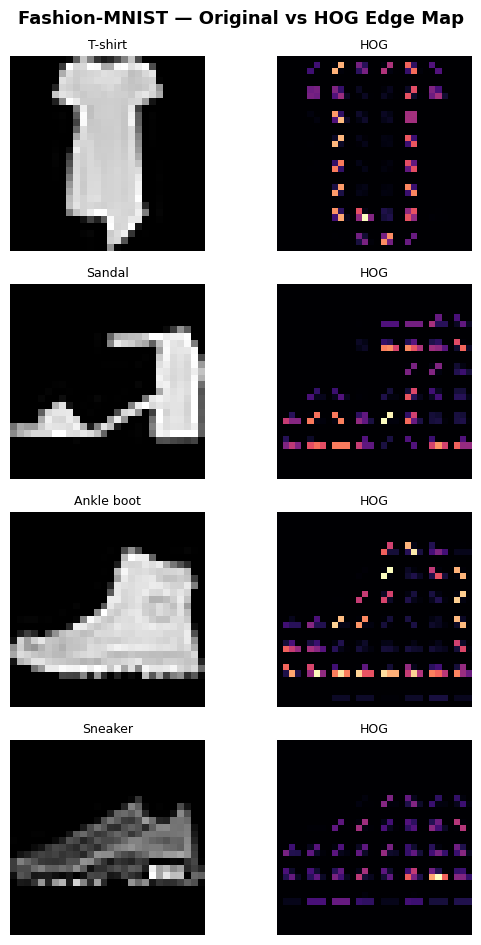


[2] PCA on HOG features...
  PCA(100): explains 62.0% variance


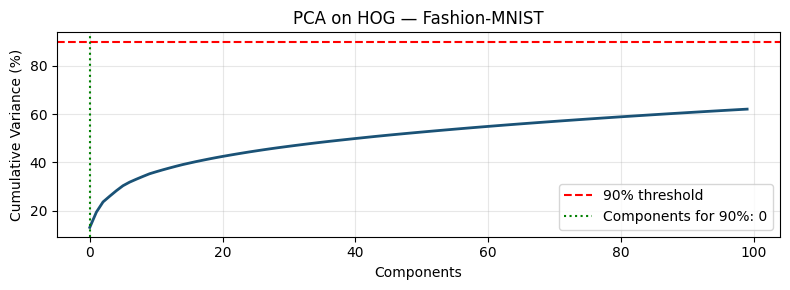


[3] SIFT Bag-of-Visual-Words...


SIFT vocab [FM]:   0%|          | 0/10000 [00:00<?, ?it/s]

  Collected 83,431 SIFT descriptors from 10,000 images
  Vocabulary built: 64 visual words


BoVW Train [FM]:   0%|          | 0/10000 [00:00<?, ?it/s]

BoVW Test  [FM]:   0%|          | 0/2000 [00:00<?, ?it/s]

  BoVW feature dim: 64

[4] PCA on BoVW features...
  PCA(63): explains 99.9% variance

[5] Raw pixels + PCA...
  PCA(100): explains 87.6% variance

All Fashion-MNIST features ready.
  HOG+PCA  train: (10000, 100)
  BoVW+PCA train: (10000, 63)
  Raw+PCA  train: (10000, 100)


In [ ]:

print("\n=== Feature Extraction: Fashion-MNIST ===")

# ── HOG ──────────────────────────────────────────────────────
print("\n[1] HOG Extraction...")
FM_hog_train = extract_hog(FM_X_train_f, desc="HOG Train [FM]")
FM_hog_test  = extract_hog(FM_X_test_f,  desc="HOG Test  [FM]")
print(f"  HOG feature dim: {FM_hog_train.shape[1]}")
visualize_hog_sample(FM_X_train_f, FM_y_train, FASHION_CLASSES,
                     n=4, title="Fashion-MNIST")

# ── HOG + PCA ────────────────────────────────────────────────
print("\n[2] PCA on HOG features...")
FM_hog_pca_tr, FM_hog_pca_te, FM_hog_scaler, FM_hog_pca = apply_pca(
    FM_hog_train, FM_hog_test, n_components=PCA_COMPONENTS
)
plot_pca_variance(FM_hog_pca, title="PCA on HOG — Fashion-MNIST")

# ── SIFT / BoVW ───────────────────────────────────────────────
print("\n[3] SIFT Bag-of-Visual-Words...")
FM_vocab      = build_sift_vocabulary(FM_X_train_f, desc="SIFT vocab [FM]")
FM_bovw_train = extract_bovw(FM_X_train_f, FM_vocab, desc="BoVW Train [FM]")
FM_bovw_test  = extract_bovw(FM_X_test_f,  FM_vocab, desc="BoVW Test  [FM]")
print(f"  BoVW feature dim: {FM_bovw_train.shape[1]}")

# ── BoVW + PCA ────────────────────────────────────────────────
print("\n[4] PCA on BoVW features...")
FM_bovw_pca_tr, FM_bovw_pca_te, FM_bovw_scaler, FM_bovw_pca = apply_pca(
    FM_bovw_train, FM_bovw_test, n_components=min(PCA_COMPONENTS, SIFT_N_CLUSTERS - 1)
)

# ── Raw Pixels + PCA ─────────────────────────────────────────
print("\n[5] Raw pixels + PCA...")
FM_raw_flat_tr = FM_X_train_f.reshape(len(FM_X_train_f), -1)
FM_raw_flat_te = FM_X_test_f.reshape(len(FM_X_test_f),   -1)
FM_raw_pca_tr, FM_raw_pca_te, FM_raw_scaler, FM_raw_pca = apply_pca(
    FM_raw_flat_tr, FM_raw_flat_te, n_components=PCA_COMPONENTS
)

print("\nAll Fashion-MNIST features ready.")
print(f"  HOG+PCA  train: {FM_hog_pca_tr.shape}")
print(f"  BoVW+PCA train: {FM_bovw_pca_tr.shape}")
print(f"  Raw+PCA  train: {FM_raw_pca_tr.shape}")


## Cell 9 — Fashion-MNIST: Classical Models on HOG+PCA Features


  FASHION-MNIST — HOG + PCA Features

── KNN ──────────────────────────────────────────────
    k= 1: Test Acc=0.8570
    k= 3: Test Acc=0.8685
    k= 5: Test Acc=0.8680
    k= 7: Test Acc=0.8695
    k=11: Test Acc=0.8715
  → Best k=11  Acc=0.8715
  KNN(k=11) [HOG+PCA]                           Acc=0.8715  F1=0.8691


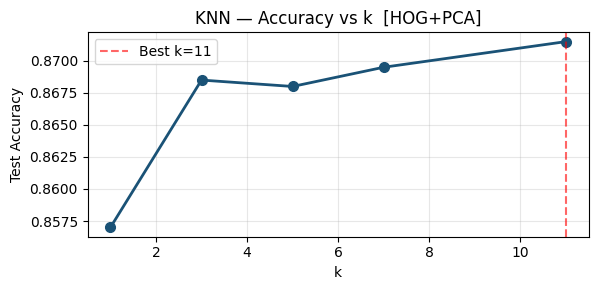


── Logistic Regression ──────────────────────────────
    C=0.010: Test Acc=0.8690
    C=0.100: Test Acc=0.8630
    C=1.000: Test Acc=0.8615
    C=10.000: Test Acc=0.8595
  → Best C=0.01  Acc=0.8690
  LogReg(C=0.01) [HOG+PCA]                      Acc=0.8690  F1=0.8688


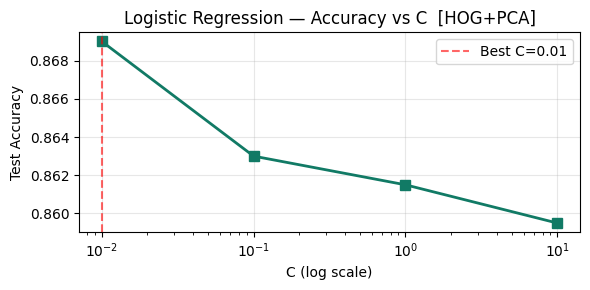


── MLP ──────────────────────────────────────────────
  MLP [HOG+PCA]                                 Acc=0.8795  F1=0.8809


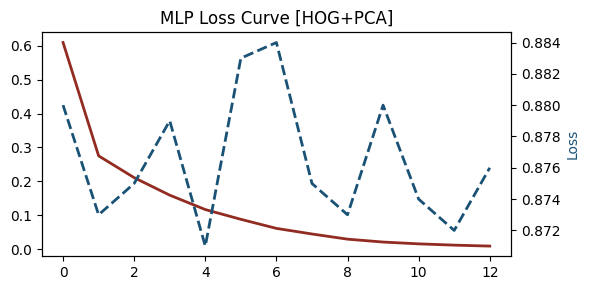


── SVM (Bonus) ───────────────────────────────────────
    C=0.10: Test Acc=0.8510
    C=1.00: Test Acc=0.8910
    C=10.00: Test Acc=0.8870
  → Best C=1.0  Acc=0.8910
  SVM(C=1.0) [HOG+PCA]                          Acc=0.8910  F1=0.8901

── Naive Bayes (Bonus) ───────────────────────────────
  NaiveBayes [HOG+PCA]                          Acc=0.7955  F1=0.7939

HOG+PCA block complete.


In [ ]:

FM_results = {}   # master results dict for Fashion-MNIST

print("\n" + "="*60)
print("  FASHION-MNIST — HOG + PCA Features")
print("="*60)

# KNN
fm_knn_hog = train_knn(FM_hog_pca_tr, FM_y_train,
                        FM_hog_pca_te, FM_y_test,
                        FASHION_CLASSES, FM_results, "HOG+PCA")

# Logistic Regression
fm_lr_hog = train_lr(FM_hog_pca_tr, FM_y_train,
                     FM_hog_pca_te, FM_y_test,
                     FASHION_CLASSES, FM_results, "HOG+PCA")

# MLP
fm_mlp_hog = train_mlp(FM_hog_pca_tr, FM_y_train,
                       FM_hog_pca_te, FM_y_test,
                       FASHION_CLASSES, FM_results, "HOG+PCA")

# SVM (Bonus)
fm_svm_hog = train_svm(FM_hog_pca_tr, FM_y_train,
                       FM_hog_pca_te, FM_y_test,
                       FASHION_CLASSES, FM_results, "HOG+PCA")

# Naive Bayes (Bonus)
fm_nb_hog = train_nb(FM_hog_pca_tr, FM_y_train,
                     FM_hog_pca_te, FM_y_test,
                     FASHION_CLASSES, FM_results, "HOG+PCA")

print("\nHOG+PCA block complete.")


## Cell 10 — Fashion-MNIST: Classical Models on SIFT/BoVW+PCA


  FASHION-MNIST — SIFT BoVW + PCA Features

── KNN ──────────────────────────────────────────────
    k= 1: Test Acc=0.4765
    k= 3: Test Acc=0.4875
    k= 5: Test Acc=0.5125
    k= 7: Test Acc=0.5165
    k=11: Test Acc=0.5045
  → Best k=7  Acc=0.5165
  KNN(k=7) [SIFT+PCA]                           Acc=0.5165  F1=0.5115


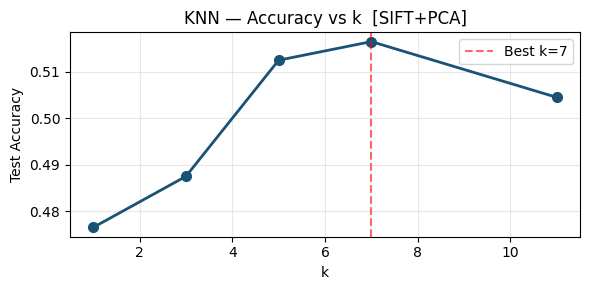


── Logistic Regression ──────────────────────────────
    C=0.010: Test Acc=0.5505
    C=0.100: Test Acc=0.5525
    C=1.000: Test Acc=0.5505
    C=10.000: Test Acc=0.5495
  → Best C=0.1  Acc=0.5525
  LogReg(C=0.1) [SIFT+PCA]                      Acc=0.5525  F1=0.5482


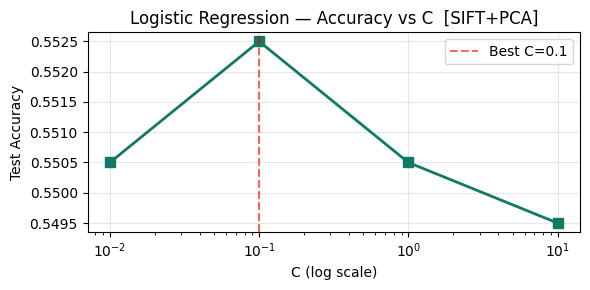


── SVM (Bonus) ───────────────────────────────────────
    C=0.10: Test Acc=0.5440
    C=1.00: Test Acc=0.5975
    C=10.00: Test Acc=0.5665
  → Best C=1.0  Acc=0.5975
  SVM(C=1.0) [SIFT+PCA]                         Acc=0.5975  F1=0.5936

SIFT+PCA block complete.


In [ ]:

print("\n" + "="*60)
print("  FASHION-MNIST — SIFT BoVW + PCA Features")
print("="*60)

train_knn(FM_bovw_pca_tr, FM_y_train, FM_bovw_pca_te, FM_y_test,
          FASHION_CLASSES, FM_results, "SIFT+PCA")

train_lr(FM_bovw_pca_tr, FM_y_train, FM_bovw_pca_te, FM_y_test,
         FASHION_CLASSES, FM_results, "SIFT+PCA")

train_svm(FM_bovw_pca_tr, FM_y_train, FM_bovw_pca_te, FM_y_test,
          FASHION_CLASSES, FM_results, "SIFT+PCA")

print("\nSIFT+PCA block complete.")


## Cell 11 — Fashion-MNIST: CNN (Raw Pixels, End-to-End)


  FASHION-MNIST — CNN (Raw Pixels)

── CNN (Fashion-MNIST) ──────────────────────────────
  Epoch  1/20  Loss=1.2038  TrainAcc=0.5571  TestAcc=0.7575
  Epoch  5/20  Loss=0.4871  TrainAcc=0.8257  TestAcc=0.8485
  Epoch 10/20  Loss=0.3627  TrainAcc=0.8694  TestAcc=0.8770
  Epoch 15/20  Loss=0.2919  TrainAcc=0.8945  TestAcc=0.8880
  Epoch 20/20  Loss=0.2697  TrainAcc=0.8992  TestAcc=0.8915
  → CNN Best Test Acc=0.8945  F1=0.8910


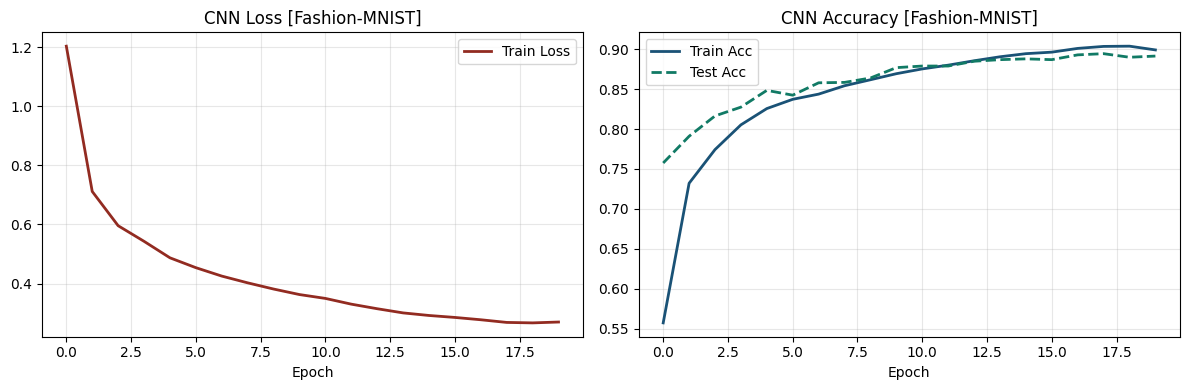

CNN training complete.


In [ ]:

print("\n" + "="*60)
print("  FASHION-MNIST — CNN (Raw Pixels)")
print("="*60)

fm_cnn = train_cnn(
    X_train_raw=FM_X_train_raw,
    y_train=FM_y_train,
    X_test_raw=FM_X_test_raw,
    y_test=FM_y_test,
    in_channels=1,
    num_classes=10,
    class_names=FASHION_CLASSES,
    results=FM_results,
    dataset_name="Fashion-MNIST"
)
print("CNN training complete.")


## Cell 12 — Fashion-MNIST: Cross-Validation on Best Classical Model

In [ ]:

print("\n── 5-Fold Cross-Validation on best classical models (HOG+PCA) ──")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

for tag, model in [("LR", fm_lr_hog), ("SVM", fm_svm_hog)]:
    scores = cross_val_score(model, FM_hog_pca_tr, FM_y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"  {tag}: CV={scores.mean():.4f} ± {scores.std():.4f}  |  per-fold: {np.round(scores,4)}")



── 5-Fold Cross-Validation on best classical models (HOG+PCA) ──
  LR: CV=0.8669 ± 0.0045  |  per-fold: [0.8635 0.8685 0.8705 0.872  0.86  ]
  SVM: CV=0.8880 ± 0.0054  |  per-fold: [0.887  0.886  0.8965 0.8905 0.88  ]


## Cell 13 — Fashion-MNIST: Full Comparative Analysis & Visualizations


  FASHION-MNIST — COMPARATIVE ANALYSIS

  RESULTS SUMMARY — Fashion-MNIST
  Classifier                                        Acc      F1
  -------------------------------------------------------------
  CNN [Fashion-MNIST]                            0.8945  0.8910 ◀ BEST
  SVM(C=1.0) [HOG+PCA]                           0.8910  0.8901
  MLP [HOG+PCA]                                  0.8795  0.8809
  KNN(k=11) [HOG+PCA]                            0.8715  0.8691
  LogReg(C=0.01) [HOG+PCA]                       0.8690  0.8688
  NaiveBayes [HOG+PCA]                           0.7955  0.7939
  SVM(C=1.0) [SIFT+PCA]                          0.5975  0.5936
  LogReg(C=0.1) [SIFT+PCA]                       0.5525  0.5482
  KNN(k=7) [SIFT+PCA]                            0.5165  0.5115



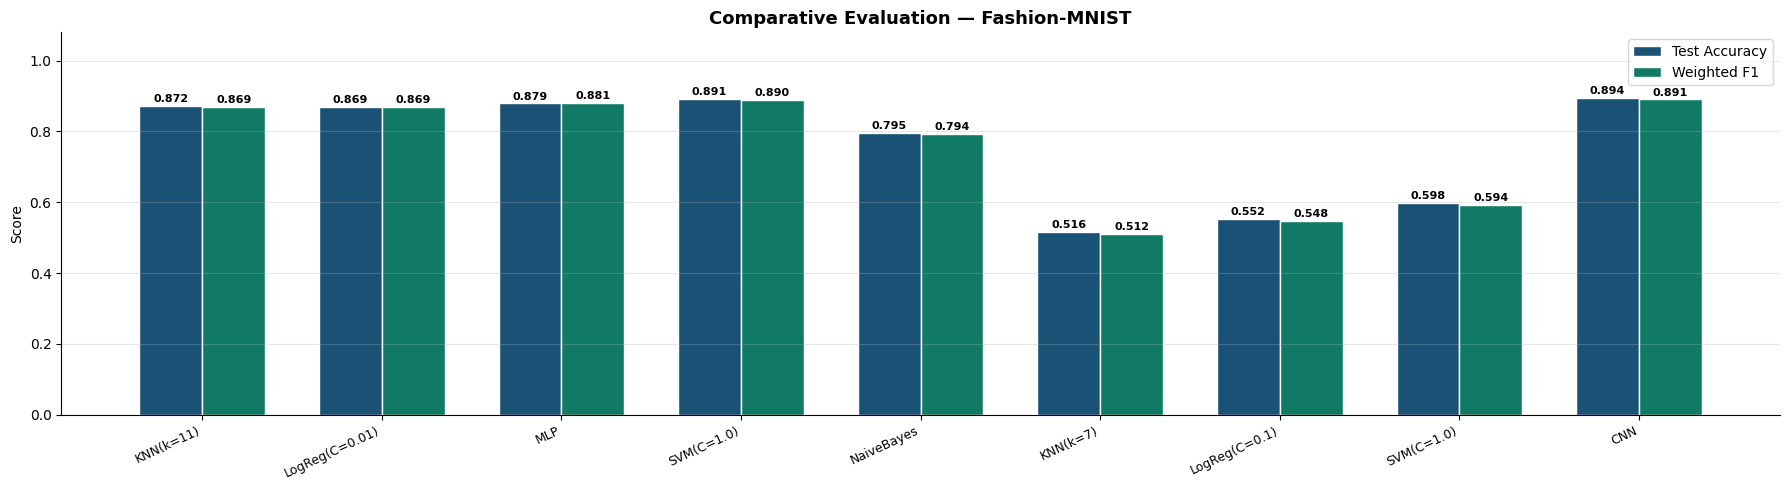

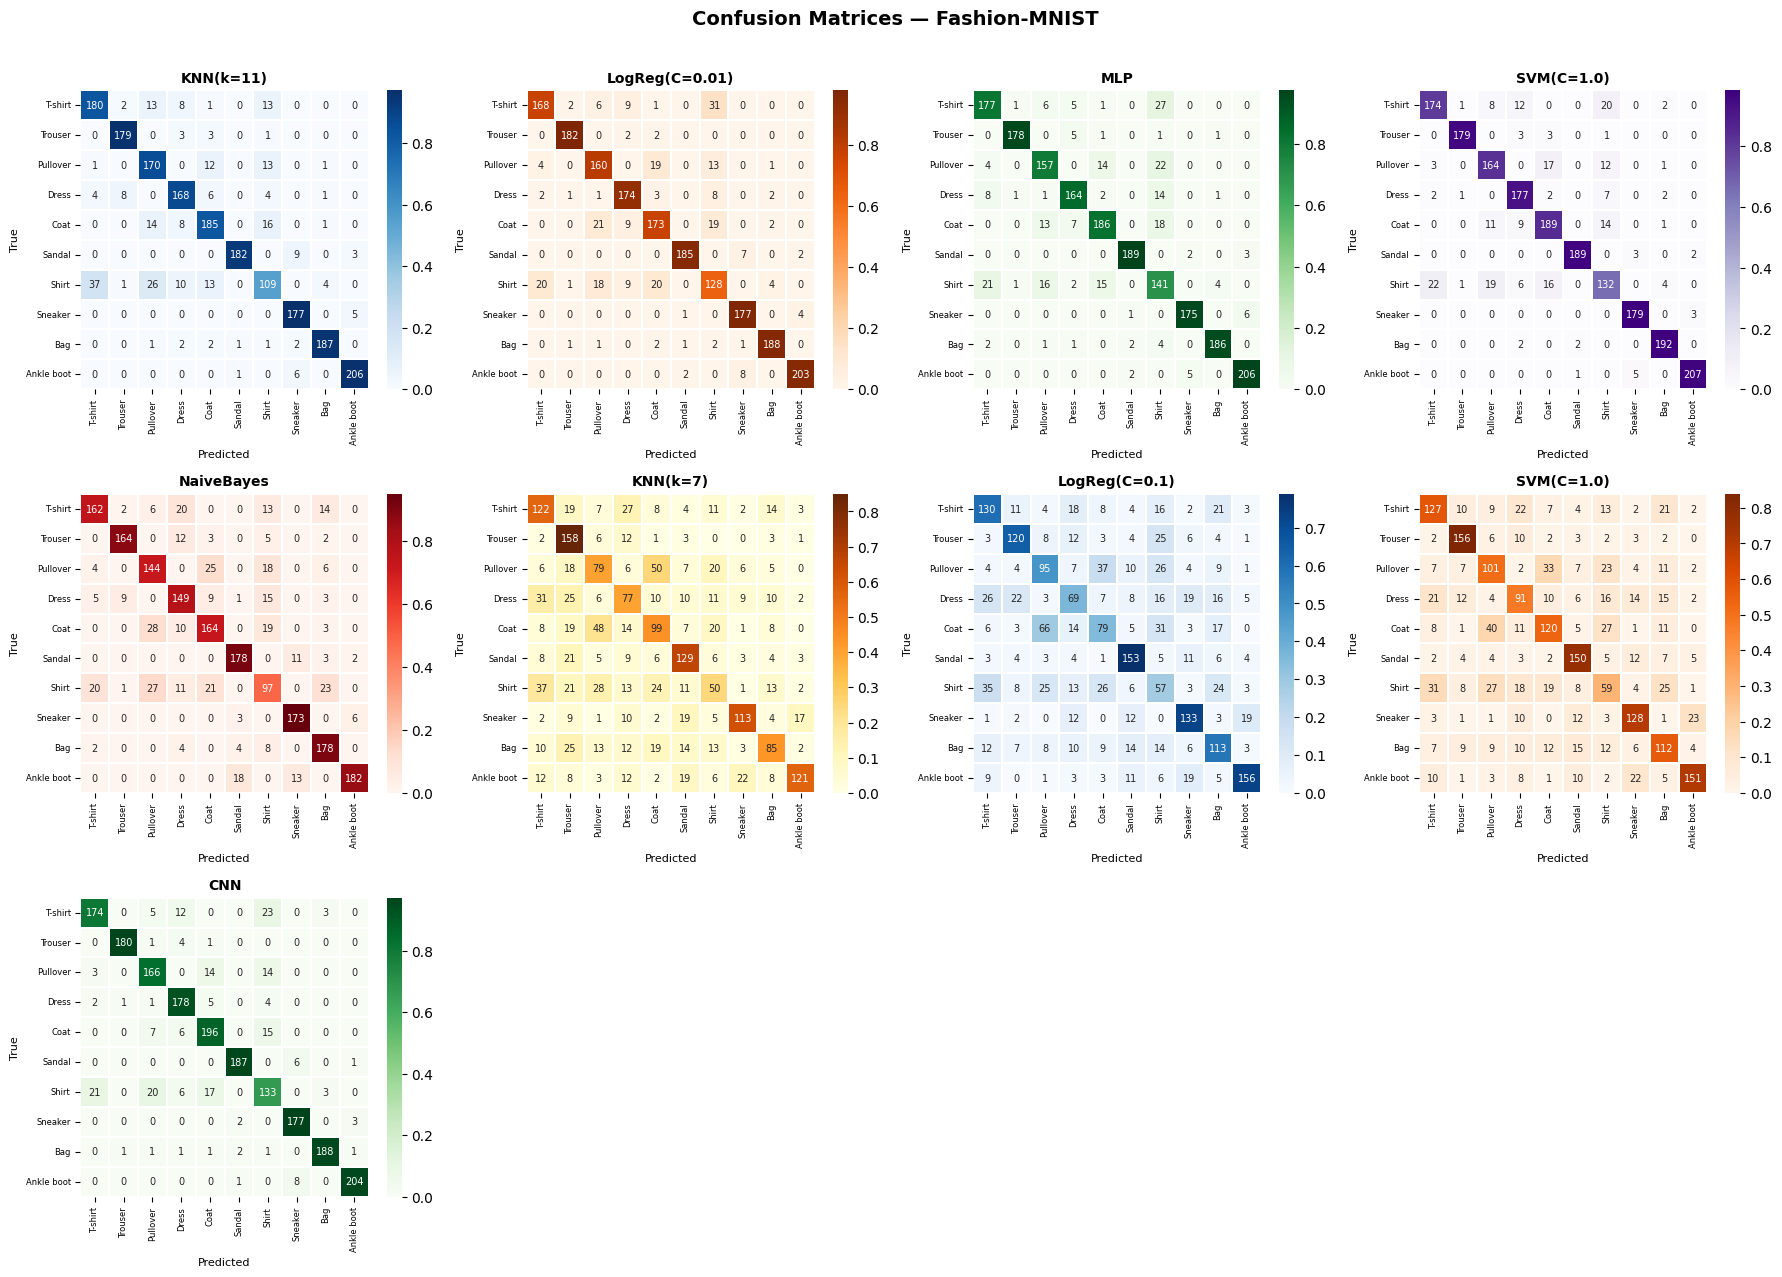

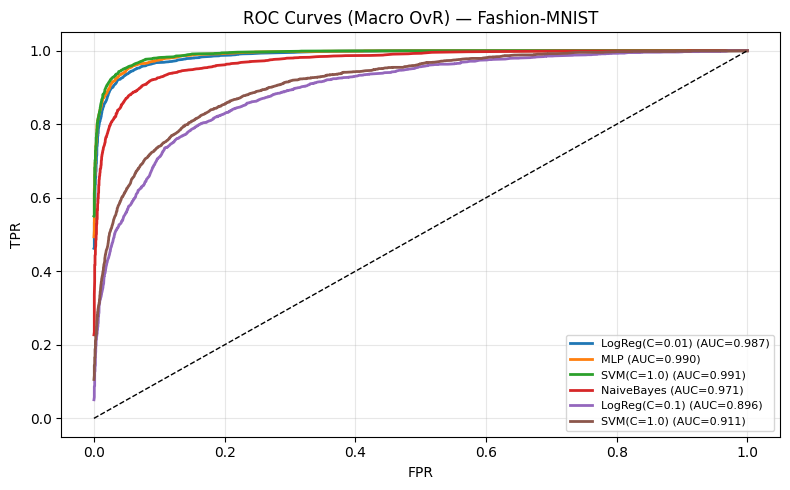

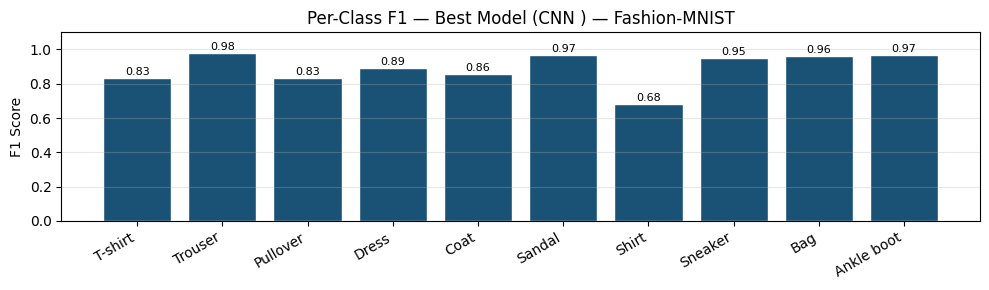


✅ Fashion-MNIST best model: CNN [Fashion-MNIST]
   Test Acc = 0.8945  |  F1 = 0.8910


In [ ]:

print("\n" + "="*60)
print("  FASHION-MNIST — COMPARATIVE ANALYSIS")
print("="*60)

# ── Summary table ─────────────────────────────────────────────
fm_best_key, fm_best_res = print_summary_table(FM_results, "Fashion-MNIST")

# ── Accuracy & F1 bar chart ────────────────────────────────────
plot_comparative_bar(FM_results, "Fashion-MNIST")

# ── Confusion matrices grid ────────────────────────────────────
plot_confusion_matrices(FM_results, FASHION_CLASSES, "Fashion-MNIST")

# ── ROC curves (probabilistic classifiers) ─────────────────────
roc_data = []
for key, res in FM_results.items():
    if not res['proba'] or isinstance(res['model'], SmallCNN):
        continue
    try:
        probas = res['model'].predict_proba(
            FM_hog_pca_te if 'HOG' in key else FM_bovw_pca_te
        )
        roc_data.append((key.split('[')[0].strip(), FM_y_test, probas))
    except Exception:
        pass
if roc_data:
    plot_roc_proper(roc_data, "Fashion-MNIST")

# ── Per-class F1 heatmap ───────────────────────────────────────
best_pred  = fm_best_res['y_pred']
# y_test aligned for non-CNN models
y_ref      = FM_y_test
if 'CNN' in fm_best_key:
    y_ref  = fm_best_res.get('y_true_cnn', FM_y_test)
report_dict = classification_report(y_ref, best_pred,
                                    target_names=FASHION_CLASSES,
                                    output_dict=True)
per_class_f1 = [report_dict[c]['f1-score'] for c in FASHION_CLASSES]

plt.figure(figsize=(10, 3))
bars = plt.bar(FASHION_CLASSES, per_class_f1, color='#1A5276', edgecolor='white')
for bar, f1v in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{f1v:.2f}', ha='center', va='bottom', fontsize=8)
plt.ylim(0, 1.1); plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 Score')
plt.title(f'Per-Class F1 — Best Model ({fm_best_key.split("[")[0]}) — Fashion-MNIST')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n✅ Fashion-MNIST best model: {fm_best_key}")
print(f"   Test Acc = {fm_best_res['acc']:.4f}  |  F1 = {fm_best_res['f1']:.4f}")

# Save best FM model info
FM_BEST_MODEL  = fm_best_res['model']
FM_BEST_KEY    = fm_best_key
FM_BEST_SCALER = FM_hog_scaler if 'HOG' in fm_best_key else (
                  FM_bovw_scaler if 'SIFT' in fm_best_key else FM_raw_scaler)
FM_BEST_PCA    = FM_hog_pca if 'HOG' in fm_best_key else (
                  FM_bovw_pca if 'SIFT' in fm_best_key else FM_raw_pca)
FM_IS_CNN      = isinstance(FM_BEST_MODEL, SmallCNN)


## Save Fashion-MNIST Models for Persistence

To ensure the best Fashion-MNIST model and its associated preprocessing components (scaler, PCA, and SIFT vocabulary if used) are available across sessions, we will save them to a file using `pickle`.

In [ ]:
import pickle

# Define a filename for the Fashion-MNIST models
FM_MODELS_FILENAME = 'fashion_mnist_models.pkl'

# Collect all relevant Fashion-MNIST objects into a dictionary
fm_models_to_save = {
    'FM_BEST_MODEL': FM_BEST_MODEL,
    'FM_BEST_SCALER': FM_BEST_SCALER,
    'FM_BEST_PCA': FM_BEST_PCA,
    'FM_BEST_KEY': FM_BEST_KEY,
    'FM_IS_CNN': FM_IS_CNN
}

# Only add FM_vocab if it exists and was used (i.e., SIFT was part of the best key)
if 'SIFT' in FM_BEST_KEY and 'FM_vocab' in globals():
    fm_models_to_save['FM_vocab'] = FM_vocab

# Save the dictionary to a file
with open(FM_MODELS_FILENAME, 'wb') as f:
    pickle.dump(fm_models_to_save, f)

print(f"Fashion-MNIST models and components saved to '{FM_MODELS_FILENAME}'")

Fashion-MNIST models and components saved to 'fashion_mnist_models.pkl'


---
# 📦 DATASET 2 — CIFAR-10
## Cell 14 — Load CIFAR-10


Loading CIFAR-10...


100%|██████████| 170M/170M [09:07<00:00, 311kB/s]


Train: (10000, 32, 32, 3)  Test: (2000, 32, 32, 3)


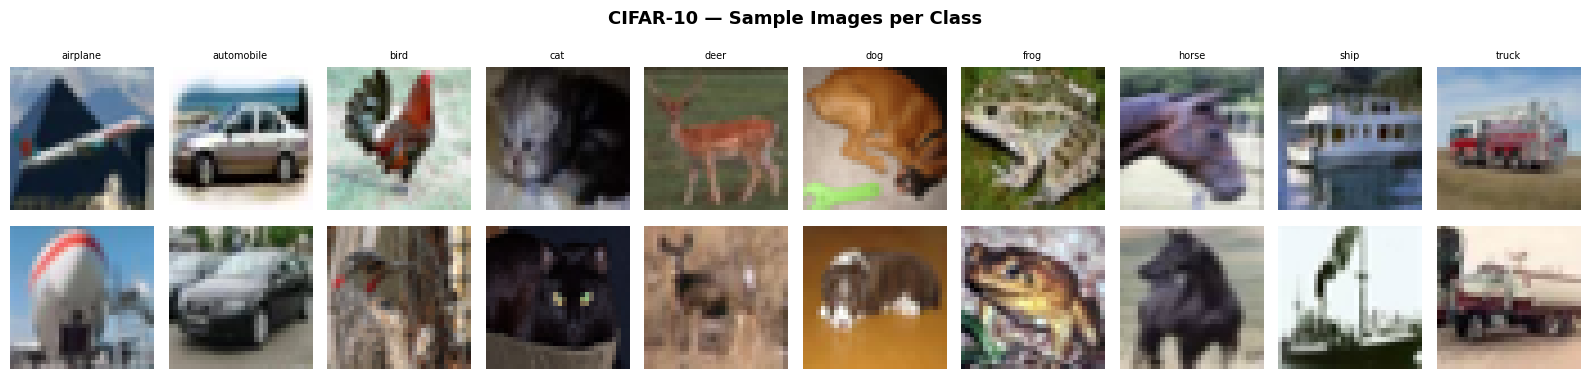

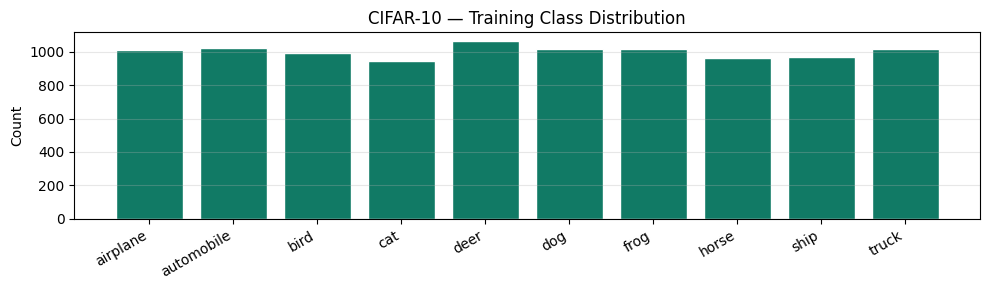

In [ ]:

print("Loading CIFAR-10...")
cf_train_ds = datasets.CIFAR10(root='./data', train=True,  download=True, transform=_transform)
cf_test_ds  = datasets.CIFAR10(root='./data', train=False, download=True, transform=_transform)

# Raw arrays (N, 32, 32, 3) uint8
CF_X_train_raw = cf_train_ds.data          # already numpy
CF_y_train     = np.array(cf_train_ds.targets)
CF_X_test_raw  = cf_test_ds.data
CF_y_test      = np.array(cf_test_ds.targets)

if TRAIN_SUBSAMPLE:
    idx = np.random.choice(len(CF_X_train_raw), TRAIN_SUBSAMPLE, replace=False)
    CF_X_train_raw = CF_X_train_raw[idx]; CF_y_train = CF_y_train[idx]
if TEST_SUBSAMPLE:
    idx = np.random.choice(len(CF_X_test_raw), TEST_SUBSAMPLE, replace=False)
    CF_X_test_raw = CF_X_test_raw[idx]; CF_y_test = CF_y_test[idx]

# Grayscale float for feature extraction
def rgb_to_gray_batch(X):
    """(N,H,W,3) uint8 → (N,H,W) float32 [0,1]"""
    return (0.2989*X[:,:,:,0] + 0.5870*X[:,:,:,1] + 0.1140*X[:,:,:,2]).astype(np.float32) / 255.0

CF_X_train_gray = rgb_to_gray_batch(CF_X_train_raw)
CF_X_test_gray  = rgb_to_gray_batch(CF_X_test_raw)

print(f"Train: {CF_X_train_raw.shape}  Test: {CF_X_test_raw.shape}")

# Sample grid
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for c in range(10):
    idx = np.where(CF_y_train == c)[0][0]
    axes[0, c].imshow(CF_X_train_raw[idx]); axes[0, c].axis('off')
    axes[0, c].set_title(CIFAR_CLASSES[c], fontsize=7)
    idx2 = np.where(CF_y_train == c)[0][1]
    axes[1, c].imshow(CF_X_train_raw[idx2]); axes[1, c].axis('off')
plt.suptitle('CIFAR-10 — Sample Images per Class', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Distribution
uniq, cnt = np.unique(CF_y_train, return_counts=True)
plt.figure(figsize=(10, 3))
plt.bar([CIFAR_CLASSES[i] for i in uniq], cnt, color='#117A65', edgecolor='white')
plt.title('CIFAR-10 — Training Class Distribution')
plt.xticks(rotation=30, ha='right'); plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


## Cell 15 — CIFAR-10: HOG + SIFT/BoVW + PCA


=== Feature Extraction: CIFAR-10 ===

[1] HOG Extraction (grayscale)...


HOG Train [CF]:   0%|          | 0/10000 [00:00<?, ?it/s]

HOG Test  [CF]:   0%|          | 0/2000 [00:00<?, ?it/s]

  HOG feature dim: 1764


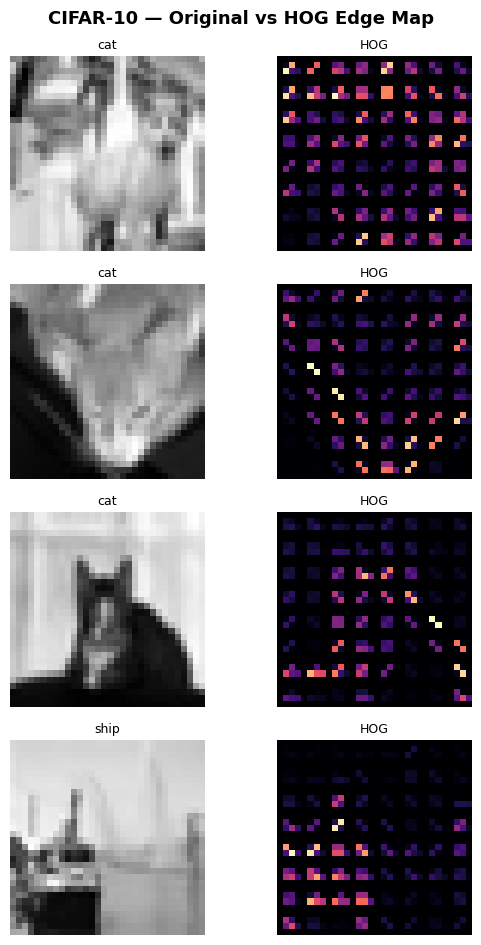


[2] PCA on HOG features...
  PCA(100): explains 47.6% variance


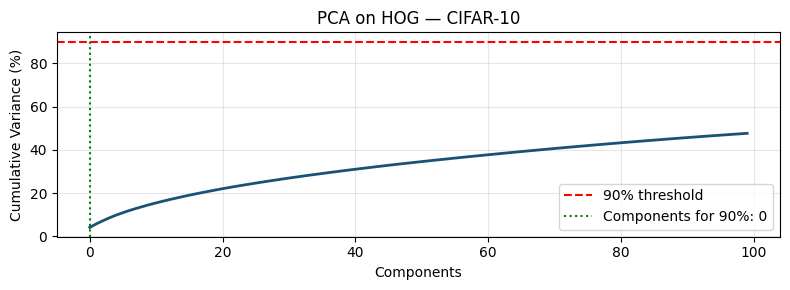


[3] SIFT Bag-of-Visual-Words (grayscale)...


SIFT vocab [CF]:   0%|          | 0/10000 [00:00<?, ?it/s]

  Collected 131,115 SIFT descriptors from 10,000 images
  Vocabulary built: 64 visual words


BoVW Train [CF]:   0%|          | 0/10000 [00:00<?, ?it/s]

BoVW Test  [CF]:   0%|          | 0/2000 [00:00<?, ?it/s]


[4] PCA on BoVW features...
  PCA(63): explains 100.0% variance

[5] Raw RGB pixels + PCA...
  PCA(100): explains 90.0% variance

All CIFAR-10 features ready.


In [ ]:

print("\n=== Feature Extraction: CIFAR-10 ===")

print("\n[1] HOG Extraction (grayscale)...")
CF_hog_train = extract_hog(CF_X_train_gray, desc="HOG Train [CF]")
CF_hog_test  = extract_hog(CF_X_test_gray,  desc="HOG Test  [CF]")
print(f"  HOG feature dim: {CF_hog_train.shape[1]}")
visualize_hog_sample(CF_X_train_gray, CF_y_train, CIFAR_CLASSES,
                     n=4, title="CIFAR-10")

print("\n[2] PCA on HOG features...")
CF_hog_pca_tr, CF_hog_pca_te, CF_hog_scaler, CF_hog_pca = apply_pca(
    CF_hog_train, CF_hog_test, n_components=PCA_COMPONENTS
)
plot_pca_variance(CF_hog_pca, title="PCA on HOG — CIFAR-10")

print("\n[3] SIFT Bag-of-Visual-Words (grayscale)...")
CF_vocab      = build_sift_vocabulary(CF_X_train_gray, desc="SIFT vocab [CF]")
CF_bovw_train = extract_bovw(CF_X_train_gray, CF_vocab, desc="BoVW Train [CF]")
CF_bovw_test  = extract_bovw(CF_X_test_gray,  CF_vocab, desc="BoVW Test  [CF]")

print("\n[4] PCA on BoVW features...")
CF_bovw_pca_tr, CF_bovw_pca_te, CF_bovw_scaler, CF_bovw_pca = apply_pca(
    CF_bovw_train, CF_bovw_test, n_components=min(PCA_COMPONENTS, SIFT_N_CLUSTERS - 1)
)

# CIFAR raw color pixels + PCA (flatten R,G,B channels)
print("\n[5] Raw RGB pixels + PCA...")
CF_raw_flat_tr = CF_X_train_raw.reshape(len(CF_X_train_raw), -1).astype(np.float32) / 255.0
CF_raw_flat_te = CF_X_test_raw.reshape(len(CF_X_test_raw),   -1).astype(np.float32) / 255.0
CF_raw_pca_tr, CF_raw_pca_te, CF_raw_scaler, CF_raw_pca = apply_pca(
    CF_raw_flat_tr, CF_raw_flat_te, n_components=PCA_COMPONENTS
)

print("\nAll CIFAR-10 features ready.")


## Cell 16 — CIFAR-10: Classical Models on HOG+PCA


  CIFAR-10 — HOG + PCA Features

── KNN ──────────────────────────────────────────────
    k= 1: Test Acc=0.4010
    k= 3: Test Acc=0.4095
    k= 5: Test Acc=0.4260
    k= 7: Test Acc=0.4360
    k=11: Test Acc=0.4455
  → Best k=11  Acc=0.4455
  KNN(k=11) [HOG+PCA]                           Acc=0.4455  F1=0.4325


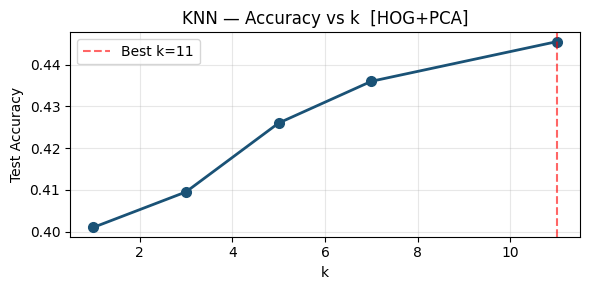


── Logistic Regression ──────────────────────────────
    C=0.010: Test Acc=0.4890
    C=0.100: Test Acc=0.4880
    C=1.000: Test Acc=0.4880
    C=10.000: Test Acc=0.4880
  → Best C=0.01  Acc=0.4890
  LogReg(C=0.01) [HOG+PCA]                      Acc=0.4890  F1=0.4859


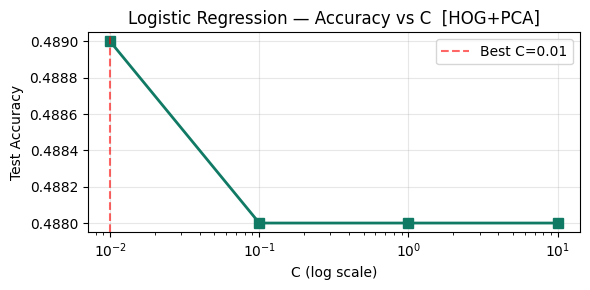


── MLP ──────────────────────────────────────────────
  MLP [HOG+PCA]                                 Acc=0.5370  F1=0.5387


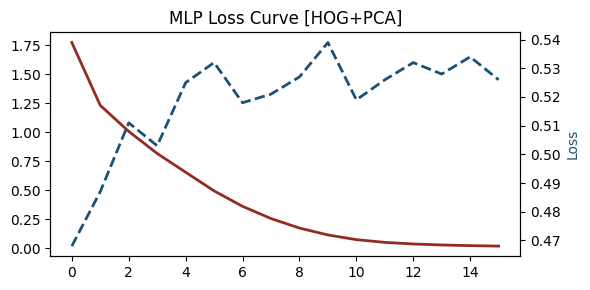


── SVM (Bonus) ───────────────────────────────────────
    C=0.10: Test Acc=0.4990
    C=1.00: Test Acc=0.5575
    C=10.00: Test Acc=0.5725
  → Best C=10.0  Acc=0.5725
  SVM(C=10.0) [HOG+PCA]                         Acc=0.5725  F1=0.5719

── Naive Bayes (Bonus) ───────────────────────────────
  NaiveBayes [HOG+PCA]                          Acc=0.4710  F1=0.4693

HOG+PCA block complete.


In [ ]:

CF_results = {}

print("\n" + "="*60)
print("  CIFAR-10 — HOG + PCA Features")
print("="*60)

train_knn(CF_hog_pca_tr, CF_y_train, CF_hog_pca_te, CF_y_test,
          CIFAR_CLASSES, CF_results, "HOG+PCA")

train_lr(CF_hog_pca_tr, CF_y_train, CF_hog_pca_te, CF_y_test,
         CIFAR_CLASSES, CF_results, "HOG+PCA")

train_mlp(CF_hog_pca_tr, CF_y_train, CF_hog_pca_te, CF_y_test,
          CIFAR_CLASSES, CF_results, "HOG+PCA")

train_svm(CF_hog_pca_tr, CF_y_train, CF_hog_pca_te, CF_y_test,
          CIFAR_CLASSES, CF_results, "HOG+PCA")

train_nb(CF_hog_pca_tr, CF_y_train, CF_hog_pca_te, CF_y_test,
         CIFAR_CLASSES, CF_results, "HOG+PCA")

print("\nHOG+PCA block complete.")


## Cell 17 — CIFAR-10: Classical Models on SIFT/BoVW+PCA


  CIFAR-10 — SIFT BoVW + PCA Features

── KNN ──────────────────────────────────────────────
    k= 1: Test Acc=0.1410
    k= 3: Test Acc=0.1580
    k= 5: Test Acc=0.1585
    k= 7: Test Acc=0.1635
    k=11: Test Acc=0.1510
  → Best k=7  Acc=0.1635
  KNN(k=7) [SIFT+PCA]                           Acc=0.1635  F1=0.1537


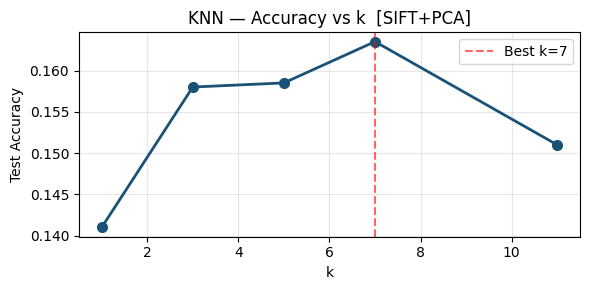


── Logistic Regression ──────────────────────────────
    C=0.010: Test Acc=0.2490
    C=0.100: Test Acc=0.2470
    C=1.000: Test Acc=0.2465
    C=10.000: Test Acc=0.2465
  → Best C=0.01  Acc=0.2490
  LogReg(C=0.01) [SIFT+PCA]                     Acc=0.2490  F1=0.2450


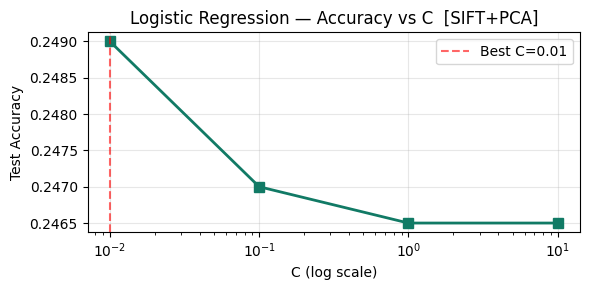


── SVM (Bonus) ───────────────────────────────────────
    C=0.10: Test Acc=0.2520
    C=1.00: Test Acc=0.2620
    C=10.00: Test Acc=0.2150
  → Best C=1.0  Acc=0.2620
  SVM(C=1.0) [SIFT+PCA]                         Acc=0.2620  F1=0.2581

SIFT+PCA block complete.


In [ ]:

print("\n" + "="*60)
print("  CIFAR-10 — SIFT BoVW + PCA Features")
print("="*60)

train_knn(CF_bovw_pca_tr, CF_y_train, CF_bovw_pca_te, CF_y_test,
          CIFAR_CLASSES, CF_results, "SIFT+PCA")

train_lr(CF_bovw_pca_tr, CF_y_train, CF_bovw_pca_te, CF_y_test,
         CIFAR_CLASSES, CF_results, "SIFT+PCA")

train_svm(CF_bovw_pca_tr, CF_y_train, CF_bovw_pca_te, CF_y_test,
          CIFAR_CLASSES, CF_results, "SIFT+PCA")

print("\nSIFT+PCA block complete.")


## Cell 18 — CIFAR-10: CNN (RGB, End-to-End)


  CIFAR-10 — CNN (RGB Raw Pixels)

── CNN (CIFAR-10) ──────────────────────────────
  Epoch  1/20  Loss=1.9881  TrainAcc=0.2550  TestAcc=0.3975
  Epoch  5/20  Loss=1.4362  TrainAcc=0.4678  TestAcc=0.5220
  Epoch 10/20  Loss=1.1854  TrainAcc=0.5709  TestAcc=0.5990
  Epoch 15/20  Loss=1.0363  TrainAcc=0.6286  TestAcc=0.6570
  Epoch 20/20  Loss=0.9819  TrainAcc=0.6482  TestAcc=0.6640
  → CNN Best Test Acc=0.6640  F1=0.6585


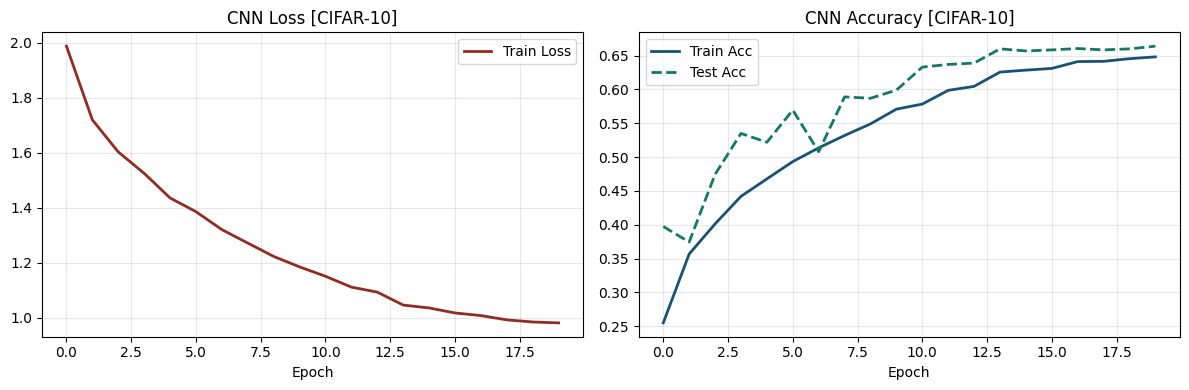

CNN training complete.


In [ ]:

print("\n" + "="*60)
print("  CIFAR-10 — CNN (RGB Raw Pixels)")
print("="*60)

cf_cnn = train_cnn(
    X_train_raw=CF_X_train_raw,
    y_train=CF_y_train,
    X_test_raw=CF_X_test_raw,
    y_test=CF_y_test,
    in_channels=3,
    num_classes=10,
    class_names=CIFAR_CLASSES,
    results=CF_results,
    dataset_name="CIFAR-10"
)
print("CNN training complete.")


## Cell 19 — CIFAR-10: Cross-Validation

In [ ]:

print("\n── 5-Fold Cross-Validation on best classical models (HOG+PCA) ──")
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# pick the LR and SVM that were trained on HOG+PCA
for key, res in CF_results.items():
    if 'HOG' not in key: continue
    model = res['model']
    if not hasattr(model, 'predict_proba'): continue
    if isinstance(model, SmallCNN): continue
    name = key.split('[')[0].strip()
    scores = cross_val_score(model, CF_hog_pca_tr, CF_y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"  {name}: CV={scores.mean():.4f} ± {scores.std():.4f}")



── 5-Fold Cross-Validation on best classical models (HOG+PCA) ──
  KNN(k=11): CV=0.4445 ± 0.0106
  LogReg(C=0.01): CV=0.4823 ± 0.0174
  MLP: CV=0.5142 ± 0.0118
  SVM(C=10.0): CV=0.5635 ± 0.0063
  NaiveBayes: CV=0.4730 ± 0.0148


## Cell 20 — CIFAR-10: Full Comparative Analysis & Visualizations


  CIFAR-10 — COMPARATIVE ANALYSIS

  RESULTS SUMMARY — CIFAR-10
  Classifier                                        Acc      F1
  -------------------------------------------------------------
  CNN [CIFAR-10]                                 0.6640  0.6585 ◀ BEST
  SVM(C=10.0) [HOG+PCA]                          0.5725  0.5719
  MLP [HOG+PCA]                                  0.5370  0.5387
  LogReg(C=0.01) [HOG+PCA]                       0.4890  0.4859
  NaiveBayes [HOG+PCA]                           0.4710  0.4693
  KNN(k=11) [HOG+PCA]                            0.4455  0.4325
  SVM(C=1.0) [SIFT+PCA]                          0.2620  0.2581
  LogReg(C=0.01) [SIFT+PCA]                      0.2490  0.2450
  KNN(k=7) [SIFT+PCA]                            0.1635  0.1537



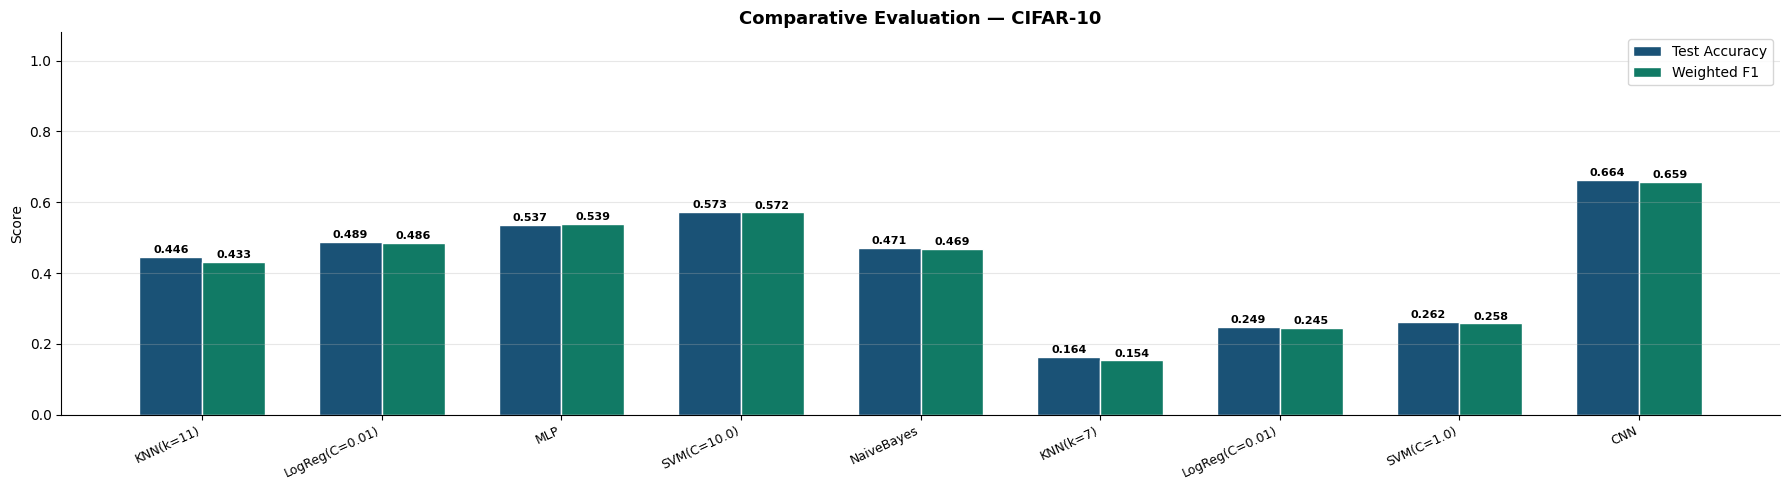

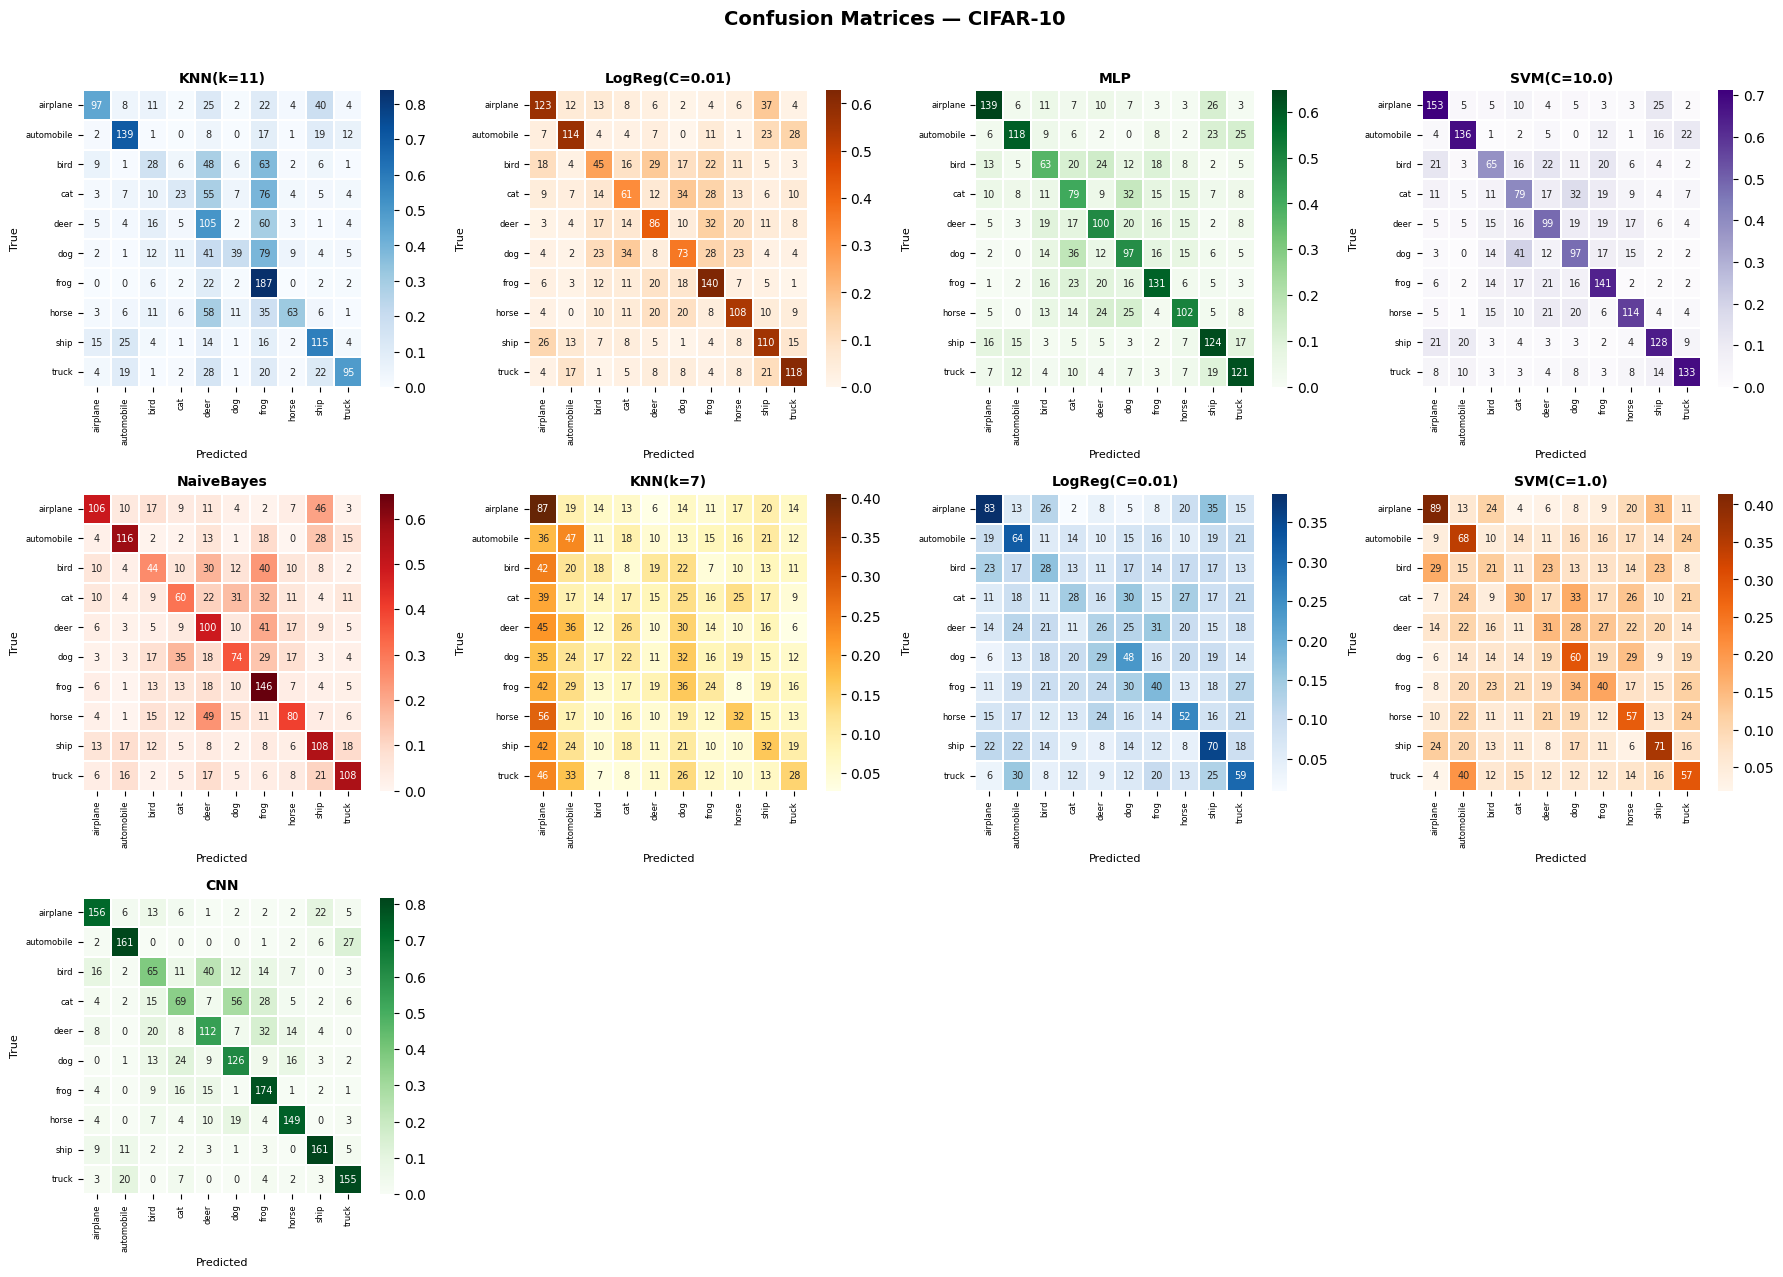

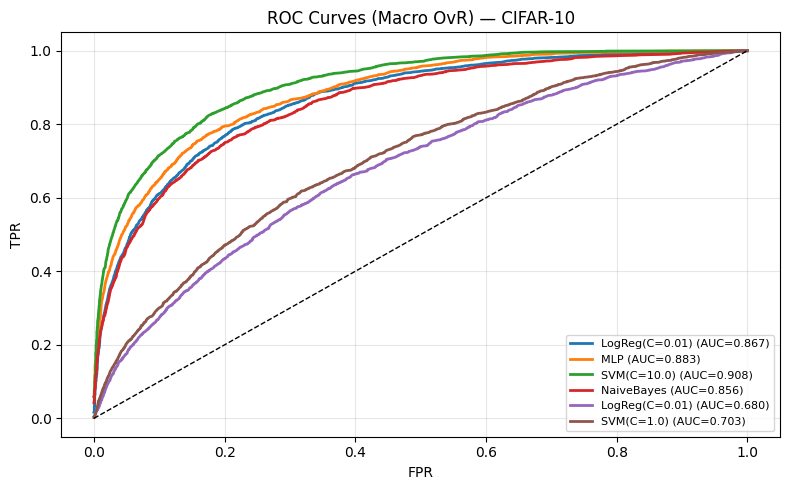

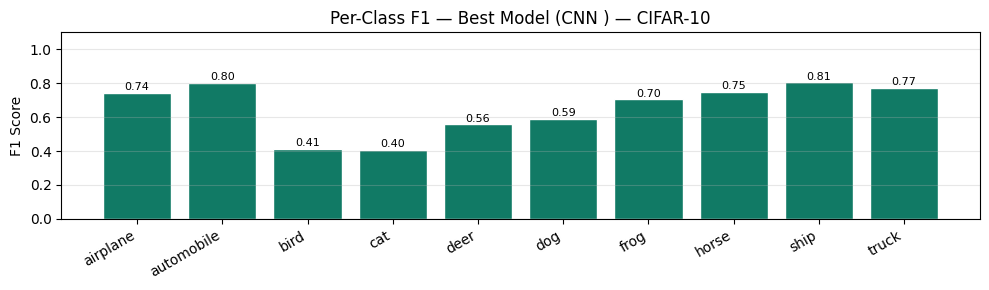


✅ CIFAR-10 best model: CNN [CIFAR-10]
   Test Acc = 0.6640  |  F1 = 0.6585


In [ ]:

print("\n" + "="*60)
print("  CIFAR-10 — COMPARATIVE ANALYSIS")
print("="*60)

cf_best_key, cf_best_res = print_summary_table(CF_results, "CIFAR-10")

plot_comparative_bar(CF_results, "CIFAR-10")
plot_confusion_matrices(CF_results, CIFAR_CLASSES, "CIFAR-10")

# ROC curves
roc_data_cf = []
for key, res in CF_results.items():
    if not res['proba'] or isinstance(res['model'], SmallCNN):
        continue
    try:
        feat = CF_hog_pca_te if 'HOG' in key else CF_bovw_pca_te
        probas = res['model'].predict_proba(feat)
        roc_data_cf.append((key.split('[')[0].strip(), CF_y_test, probas))
    except Exception:
        pass
if roc_data_cf:
    plot_roc_proper(roc_data_cf, "CIFAR-10")

# Per-class F1 bar
best_pred_cf = cf_best_res['y_pred']
y_ref_cf     = CF_y_test
if 'CNN' in cf_best_key:
    y_ref_cf = cf_best_res.get('y_true_cnn', CF_y_test)
report_cf = classification_report(y_ref_cf, best_pred_cf,
                                  target_names=CIFAR_CLASSES,
                                  output_dict=True)
per_cls_f1_cf = [report_cf[c]['f1-score'] for c in CIFAR_CLASSES]
plt.figure(figsize=(10, 3))
bars = plt.bar(CIFAR_CLASSES, per_cls_f1_cf, color='#117A65', edgecolor='white')
for bar, f1v in zip(bars, per_cls_f1_cf):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{f1v:.2f}', ha='center', va='bottom', fontsize=8)
plt.ylim(0, 1.1); plt.xticks(rotation=30, ha='right')
plt.ylabel('F1 Score')
plt.title(f'Per-Class F1 — Best Model ({cf_best_key.split("[")[0]}) — CIFAR-10')
plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n✅ CIFAR-10 best model: {cf_best_key}")
print(f"   Test Acc = {cf_best_res['acc']:.4f}  |  F1 = {cf_best_res['f1']:.4f}")

CF_BEST_MODEL  = cf_best_res['model']
CF_BEST_KEY    = cf_best_key
CF_IS_CNN      = isinstance(CF_BEST_MODEL, SmallCNN)
CF_BEST_SCALER = CF_hog_scaler if 'HOG' in cf_best_key else (
                  CF_bovw_scaler if 'SIFT' in cf_best_key else CF_raw_scaler)
CF_BEST_PCA    = CF_hog_pca if 'HOG' in cf_best_key else (
                  CF_bovw_pca if 'SIFT' in cf_best_key else CF_raw_pca)


## Save CIFAR-10 Models for Persistence

Similarly, we will save the best CIFAR-10 model and its preprocessing components to a file for persistence.

In [ ]:
import pickle

# Define a filename for the CIFAR-10 models
CIFAR_MODELS_FILENAME = 'cifar_10_models.pkl'

# Collect all relevant CIFAR-10 objects into a dictionary
cf_models_to_save = {
    'CF_BEST_MODEL': CF_BEST_MODEL,
    'CF_BEST_SCALER': CF_BEST_SCALER,
    'CF_BEST_PCA': CF_BEST_PCA,
    'CF_BEST_KEY': CF_BEST_KEY,
    'CF_IS_CNN': CF_IS_CNN
}

# Only add CF_vocab if it exists and was used
if 'SIFT' in CF_BEST_KEY and 'CF_vocab' in globals():
    cf_models_to_save['CF_vocab'] = CF_vocab

# Save the dictionary to a file
with open(CIFAR_MODELS_FILENAME, 'wb') as f:
    pickle.dump(cf_models_to_save, f)

print(f"CIFAR-10 models and components saved to '{CIFAR_MODELS_FILENAME}'")

CIFAR-10 models and components saved to 'cifar_10_models.pkl'


## Load Saved Models for Prediction

If you restart your Colab session, the trained models and preprocessing objects will no longer be in memory. Run the following cell to load them from the saved `.pkl` files, enabling predictions with your best models.

In [ ]:
import pickle

# Filenames for saved models
FM_MODELS_FILENAME = 'fashion_mnist_models.pkl'
CIFAR_MODELS_FILENAME = 'cifar_10_models.pkl'

print("Attempting to load saved models...")

# Load Fashion-MNIST models
try:
    with open(FM_MODELS_FILENAME, 'rb') as f:
        fm_loaded = pickle.load(f)

    # Assign loaded components to global variables
    globals()['FM_BEST_MODEL']  = fm_loaded['FM_BEST_MODEL']
    globals()['FM_BEST_SCALER'] = fm_loaded['FM_BEST_SCALER']
    globals()['FM_BEST_PCA']    = fm_loaded['FM_BEST_PCA']
    globals()['FM_BEST_KEY']    = fm_loaded['FM_BEST_KEY']
    globals()['FM_IS_CNN']      = fm_loaded['FM_IS_CNN']
    if 'FM_vocab' in fm_loaded: # Load vocab only if it was saved
        globals()['FM_vocab']   = fm_loaded['FM_vocab']
    else:
        globals()['FM_vocab'] = None # Ensure it's defined even if not loaded
    print(f"  Fashion-MNIST models loaded from '{FM_MODELS_FILENAME}'")
except FileNotFoundError:
    print(f"  Fashion-MNIST models not found at '{FM_MODELS_FILENAME}'. Please run full pipeline first.")
    # Set defaults if not loaded to prevent NameError in later cells
    globals()['FM_BEST_MODEL'] = None
    globals()['FM_BEST_SCALER'] = None
    globals()['FM_BEST_PCA'] = None
    globals()['FM_BEST_KEY'] = "Not Loaded"
    globals()['FM_IS_CNN'] = False
    globals()['FM_vocab'] = None
except Exception as e:
    print(f"  Error loading Fashion-MNIST models: {e}")

# Load CIFAR-10 models
try:
    with open(CIFAR_MODELS_FILENAME, 'rb') as f:
        cf_loaded = pickle.load(f)

    # Assign loaded components to global variables
    globals()['CF_BEST_MODEL']  = cf_loaded['CF_BEST_MODEL']
    globals()['CF_BEST_SCALER'] = cf_loaded['CF_BEST_SCALER']
    globals()['CF_BEST_PCA']    = cf_loaded['CF_BEST_PCA']
    globals()['CF_BEST_KEY']    = cf_loaded['CF_BEST_KEY']
    globals()['CF_IS_CNN']      = cf_loaded['CF_IS_CNN']
    if 'CF_vocab' in cf_loaded: # Load vocab only if it was saved
        globals()['CF_vocab']   = cf_loaded['CF_vocab']
    else:
        globals()['CF_vocab'] = None # Ensure it's defined even if not loaded
    print(f"  CIFAR-10 models loaded from '{CIFAR_MODELS_FILENAME}'")
except FileNotFoundError:
    print(f"  CIFAR-10 models not found at '{CIFAR_MODELS_FILENAME}'. Please run full pipeline first.")
    # Set defaults if not loaded
    globals()['CF_BEST_MODEL'] = None
    globals()['CF_BEST_SCALER'] = None
    globals()['CF_BEST_PCA'] = None
    globals()['CF_BEST_KEY'] = "Not Loaded"
    globals()['CF_IS_CNN'] = False
    globals()['CF_vocab'] = None
except Exception as e:
    print(f"  Error loading CIFAR-10 models: {e}")

print("Model loading complete (check messages above for status).")


Attempting to load saved models...
  Fashion-MNIST models loaded from 'fashion_mnist_models.pkl'
  CIFAR-10 models loaded from 'cifar_10_models.pkl'
Model loading complete (check messages above for status).


---
## Cell 21 — Cross-Dataset Comparison (Fashion-MNIST vs CIFAR-10)



  CROSS-DATASET COMPARATIVE SUMMARY

  Model                        FM Acc     FM F1    CF Acc     CF F1
  ---------------------------------------------------------------
  CNN                          0.8945    0.8910    0.6640    0.6585
  KNN(k=11)                    0.8715    0.8691    0.4455    0.4325
  KNN(k=7)                     0.5165    0.5115    0.1635    0.1537
  LogReg(C=0.01)               0.8690    0.8688    0.4890    0.4859
  LogReg(C=0.1)                0.5525    0.5482     N/A       N/A  
  MLP                          0.8795    0.8809    0.5370    0.5387
  NaiveBayes                   0.7955    0.7939    0.4710    0.4693
  SVM(C=1.0)                   0.8910    0.8901    0.2620    0.2581
  SVM(C=10.0)                   N/A       N/A      0.5725    0.5719


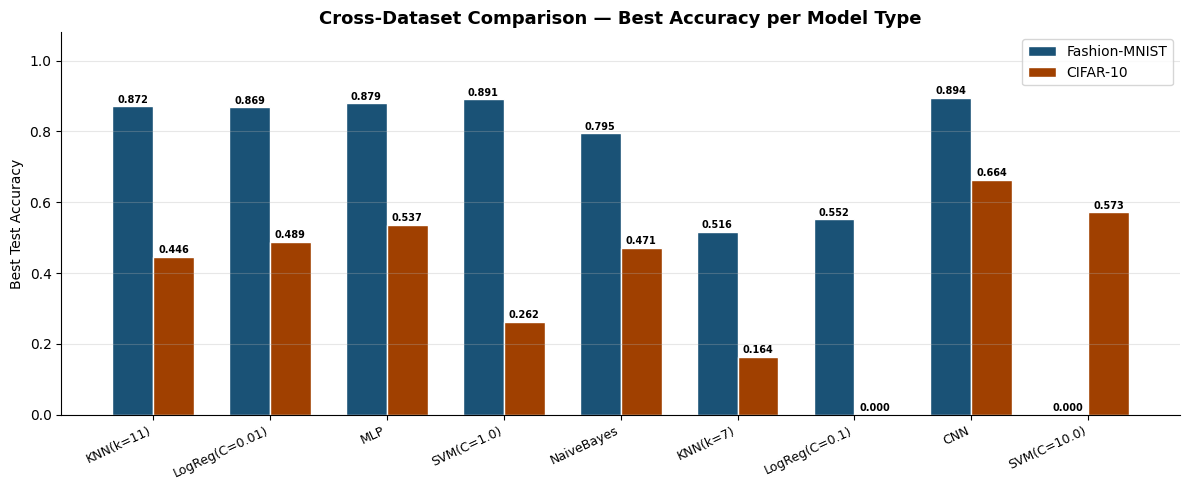


  Fashion-MNIST overall best : CNN [Fashion-MNIST]  Acc=0.8945
  CIFAR-10      overall best : CNN [CIFAR-10]  Acc=0.6640


In [ ]:

print("\n" + "="*60)
print("  CROSS-DATASET COMPARATIVE SUMMARY")
print("="*60)

# Collect best-per-model-type for both datasets
model_types = {}
for key, res in FM_results.items():
    mtype = key.split('[')[0].strip()
    if mtype not in model_types:
        model_types[mtype] = {'fm_acc': None, 'fm_f1': None, 'cf_acc': None, 'cf_f1': None}
    if model_types[mtype]['fm_acc'] is None or res['acc'] > model_types[mtype]['fm_acc']:
        model_types[mtype]['fm_acc'] = res['acc']
        model_types[mtype]['fm_f1']  = res['f1']

for key, res in CF_results.items():
    mtype = key.split('[')[0].strip()
    if mtype not in model_types:
        model_types[mtype] = {'fm_acc': None, 'fm_f1': None, 'cf_acc': None, 'cf_f1': None}
    if model_types[mtype]['cf_acc'] is None or res['acc'] > model_types[mtype]['cf_acc']:
        model_types[mtype]['cf_acc'] = res['acc']
        model_types[mtype]['cf_f1']  = res['f1']

print(f"\n  {'Model':<25} {'FM Acc':>9} {'FM F1':>9} {'CF Acc':>9} {'CF F1':>9}")
print(f"  {'-'*63}")
for mtype, vals in sorted(model_types.items()):
    fm_a = f"{vals['fm_acc']:.4f}" if vals['fm_acc'] else "  N/A  "
    fm_f = f"{vals['fm_f1']:.4f}"  if vals['fm_f1']  else "  N/A  "
    cf_a = f"{vals['cf_acc']:.4f}" if vals['cf_acc'] else "  N/A  "
    cf_f = f"{vals['cf_f1']:.4f}"  if vals['cf_f1']  else "  N/A  "
    print(f"  {mtype:<25} {fm_a:>9} {fm_f:>9} {cf_a:>9} {cf_f:>9}")

# Grouped bar: FM vs CF per model type
names   = list(model_types.keys())
fm_accs = [model_types[m]['fm_acc'] or 0 for m in names]
cf_accs = [model_types[m]['cf_acc'] or 0 for m in names]
x = np.arange(len(names)); w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, fm_accs, w, label='Fashion-MNIST', color='#1A5276', edgecolor='white')
ax.bar(x + w/2, cf_accs, w, label='CIFAR-10',      color='#A04000', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.08); ax.set_ylabel('Best Test Accuracy')
ax.set_title('Cross-Dataset Comparison — Best Accuracy per Model Type', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
for i, (fa, ca) in enumerate(zip(fm_accs, cf_accs)):
    ax.text(i - w/2, fa + 0.01, f'{fa:.3f}', ha='center', fontsize=7, fontweight='bold')
    ax.text(i + w/2, ca + 0.01, f'{ca:.3f}', ha='center', fontsize=7, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n  Fashion-MNIST overall best : {FM_BEST_KEY}  Acc={FM_results.get(FM_BEST_KEY, fm_best_res)['acc']:.4f}")
print(f"  CIFAR-10      overall best : {CF_BEST_KEY}  Acc={CF_results.get(CF_BEST_KEY, cf_best_res)['acc']:.4f}")


## Cell 22.1 — Detailed Performance Metrics for All Models

---
## Cell 22 — 🖼️ Upload Your Own Image → Best Model Predicts It

Upload **any** image. The cell will:
1. Resize and display it
2. Run it through the best Fashion-MNIST model
3. Run it through the best CIFAR-10 model
4. Show both predictions with confidence bars


Upload an image for Fashion-MNIST...


Saving bag.png to bag (1).png

Image: bag (1).png  Size: (231, 247)

[Fashion-MNIST] Running: CNN [Fashion-MNIST] ...


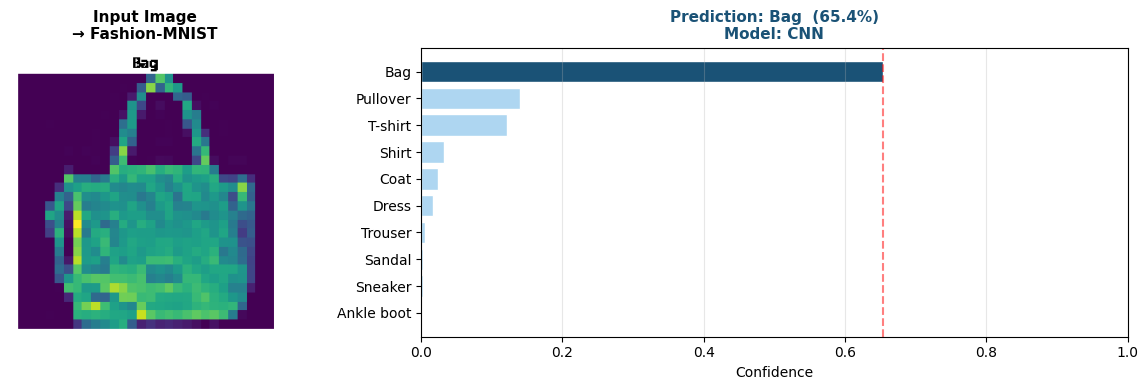


Fashion-MNIST Prediction: Bag (65.4%)


In [ ]:
# ── UPLOAD & PREDICT: Fashion-MNIST ──────────────────────────
from google.colab import files as colab_files
import io

print("Upload an image for Fashion-MNIST...")
uploaded = colab_files.upload()

for fname, data in uploaded.items():
    img_pil = Image.open(io.BytesIO(data)).convert('RGB')
    print(f"\nImage: {fname}  Size: {img_pil.size}")

    print(f"\n[Fashion-MNIST] Running: {FM_BEST_KEY} ...")

    use_vocab_fm = FM_vocab if 'SIFT' in FM_BEST_KEY else None

    fm_pred, fm_conf = predict_single(
        img_pil,
        model       = FM_BEST_MODEL,
        scaler      = FM_BEST_SCALER,
        pca         = FM_BEST_PCA,
        class_names = FASHION_CLASSES,
        is_cnn      = FM_IS_CNN,
        vocab       = use_vocab_fm,
        in_channels = 1
    )

    plot_prediction(
        img_pil,
        fm_pred,
        fm_conf,
        FASHION_CLASSES,
        "Fashion-MNIST",
        FM_BEST_KEY.split('[')[0].strip()
    )

    print("\n" + "="*50)
    print(f"Fashion-MNIST Prediction: {fm_pred} ({fm_conf[fm_pred]*100:.1f}%)")
    print("="*50)

Upload an image for CIFAR-10...


Saving images.jpg to images.jpg

Image: images.jpg  Size: (259, 194)

[CIFAR-10] Running: CNN [CIFAR-10] ...


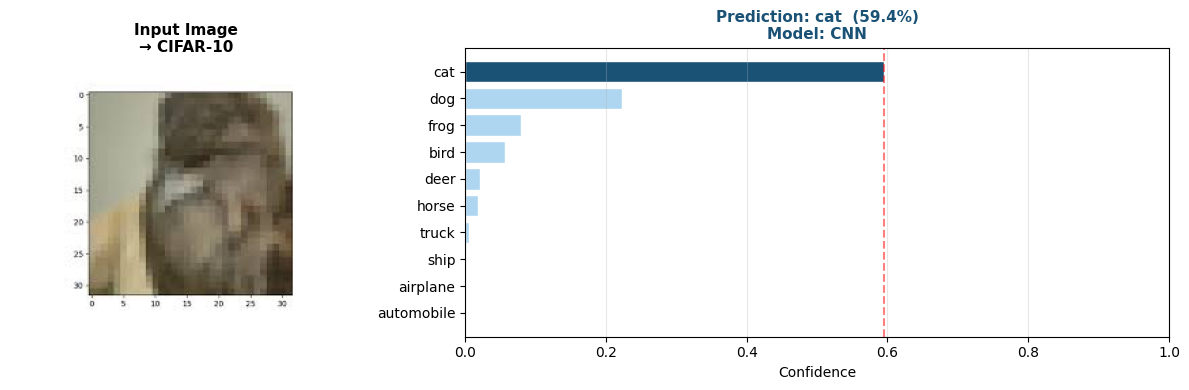


CIFAR-10 Prediction: cat (59.4%)


In [ ]:
# ── UPLOAD & PREDICT: CIFAR-10 ───────────────────────────────
from google.colab import files as colab_files
import io

print("Upload an image for CIFAR-10...")
uploaded = colab_files.upload()

for fname, data in uploaded.items():
    img_pil = Image.open(io.BytesIO(data)).convert('RGB')
    print(f"\nImage: {fname}  Size: {img_pil.size}")

    print(f"\n[CIFAR-10] Running: {CF_BEST_KEY} ...")

    use_vocab_cf = CF_vocab if 'SIFT' in CF_BEST_KEY else None

    cf_pred, cf_conf = predict_single(
        img_pil,
        model       = CF_BEST_MODEL,
        scaler      = CF_BEST_SCALER,
        pca         = CF_BEST_PCA,
        class_names = CIFAR_CLASSES,
        is_cnn      = CF_IS_CNN,
        vocab       = use_vocab_cf,
        in_channels = 3
    )

    plot_prediction(
        img_pil,
        cf_pred,
        cf_conf,
        CIFAR_CLASSES,
        "CIFAR-10",
        CF_BEST_KEY.split('[')[0].strip()
    )

    print("\n" + "="*50)
    print(f"CIFAR-10 Prediction: {cf_pred} ({cf_conf[cf_pred]*100:.1f}%)")
    print("="*50)